# TimeLapse Processing

Phase-plane shift estimation applied to real migrated timelapse data.

In [108]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal         import hilbert as sp_hilbert
from scipy.signal.windows import tukey

In [109]:

def estimate_shift_2d(base, mon, dz_g, dx_g, kz_cent, kz_pos_only=False, force_dz_zero=False):
    """
    Fit a 2D phase plane phi(kz,kx) = kz*dz + kx*dx + phi_0 to the cross-spectrum.
    Returns (dz_est, dx_est, phi_0, XS, kz_ax, kx_ax).

    kz_pos_only=True   — restrict WLS to KZ > 0 (use with analytic-signal inputs).
    force_dz_zero=True — fit only (dx, phi_0); KZ column dropped and dz_est returned
                         as 0.0. Use when vertical movement is known to be absent:
                         removes ill-conditioning from narrowband wavelet where phi_0
                         and kz*dz are nearly indistinguishable on the one-sided spectrum.
    """
    Nz, Nx = base.shape

    kz_ax = np.fft.fftfreq(Nz, d=dz_g) * 2 * np.pi
    kx_ax = np.fft.fftfreq(Nx, d=dx_g) * 2 * np.pi
    KZ, KX = np.meshgrid(kz_ax, kx_ax, indexing='ij')

    taper = np.outer(tukey(Nz, alpha=0.15), tukey(Nx, alpha=0.15))

    base_fft = np.fft.fft2(base * taper)
    mon_fft  = np.fft.fft2(mon  * taper)
    XS       = base_fft * np.conj(mon_fft)

    w   = np.abs(XS)
    phi = np.angle(XS)

    band = (np.abs(KZ) < 1.4 * kz_cent) & (np.abs(KX) < 1.4 * kz_cent)
    mask = (w > 0.10 * w.max()) & band & ((np.abs(KZ) + np.abs(KX)) > 0)
    if kz_pos_only:
        mask &= (KZ > 0)

    W = w[mask]
    if force_dz_zero:
        # 2-parameter fit: phi = kx*dx + phi_0  (dz = 0 by physics)
        A = np.column_stack([KX[mask], np.ones(mask.sum())])
        c = np.linalg.lstsq(A * W[:, None], phi[mask] * W, rcond=None)[0]
        return 0.0, c[0], c[1], XS, kz_ax, kx_ax
    else:
        # 3-parameter fit: phi = kz*dz + kx*dx + phi_0
        A = np.column_stack([KZ[mask], KX[mask], np.ones(mask.sum())])
        c = np.linalg.lstsq(A * W[:, None], phi[mask] * W, rcond=None)[0]
        return c[0], c[1], c[2], XS, kz_ax, kx_ax


## Section 1 — Load & Plot Migrated Results

In [110]:
STUDY_ROOT = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\timelapse_study')

d = np.load(str(STUDY_ROOT / 'migrated_results.npz'), allow_pickle=False)

kirchhoff         = d['kirchhoff']           # (7, n_z, n_x)
gazdag            = d['gazdag']              # (7, n_z, n_x)
backprop          = d['backprop']            # (7, n_z, n_x)
scenarios         = list(d['scenarios'])     # ['Baseline', '2lambda', ...]
separation_lambda = d['separation_lambda']   # [0, 2, 1, 0.5, 0.25, 0.125, 0.0625]
x_traces          = d['x_traces']
z_img             = d['z_img']
x_s1              = d['x_s1']
x_s2              = float(d['x_s2'])
z_scatterer       = float(d['z_scatterer'])
z_top             = float(d['z_top'])

# Physics parameters
v_ice = 0.168    # m/ns
f_c   = 1.5      # GHz
lam   = v_ice / f_c

dz_mig = float(z_img[1]    - z_img[0])
dx_mig = float(x_traces[1] - x_traces[0])
kz_c   = 2 * np.pi / lam

print(f"Loaded: {STUDY_ROOT / 'migrated_results.npz'}")
print(f"  kirchhoff : {kirchhoff.shape}")
print(f"  gazdag    : {gazdag.shape}")
print(f"  backprop  : {backprop.shape}")
print(f"  scenarios : {scenarios}")
print(f"\nGrid spacing:  dz={dz_mig*1e3:.2f} mm,  dx={dx_mig*1e3:.2f} mm")
print(f"lambda = {lam*1e3:.1f} mm,  kz_c = {kz_c:.2f} rad/m")

Loaded: C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\timelapse_study\migrated_results.npz
  kirchhoff : (8, 160, 380)
  gazdag    : (8, 160, 380)
  backprop  : (8, 160, 380)
  scenarios : [np.str_('Baseline'), np.str_('2λ'), np.str_('1λ'), np.str_('½λ'), np.str_('¼λ'), np.str_('⅛λ'), np.str_('¹⁄₁₆λ'), np.str_('¹⁄₃₂λ')]

Grid spacing:  dz=5.03 mm,  dx=10.00 mm
lambda = 112.0 mm,  kz_c = 56.10 rad/m


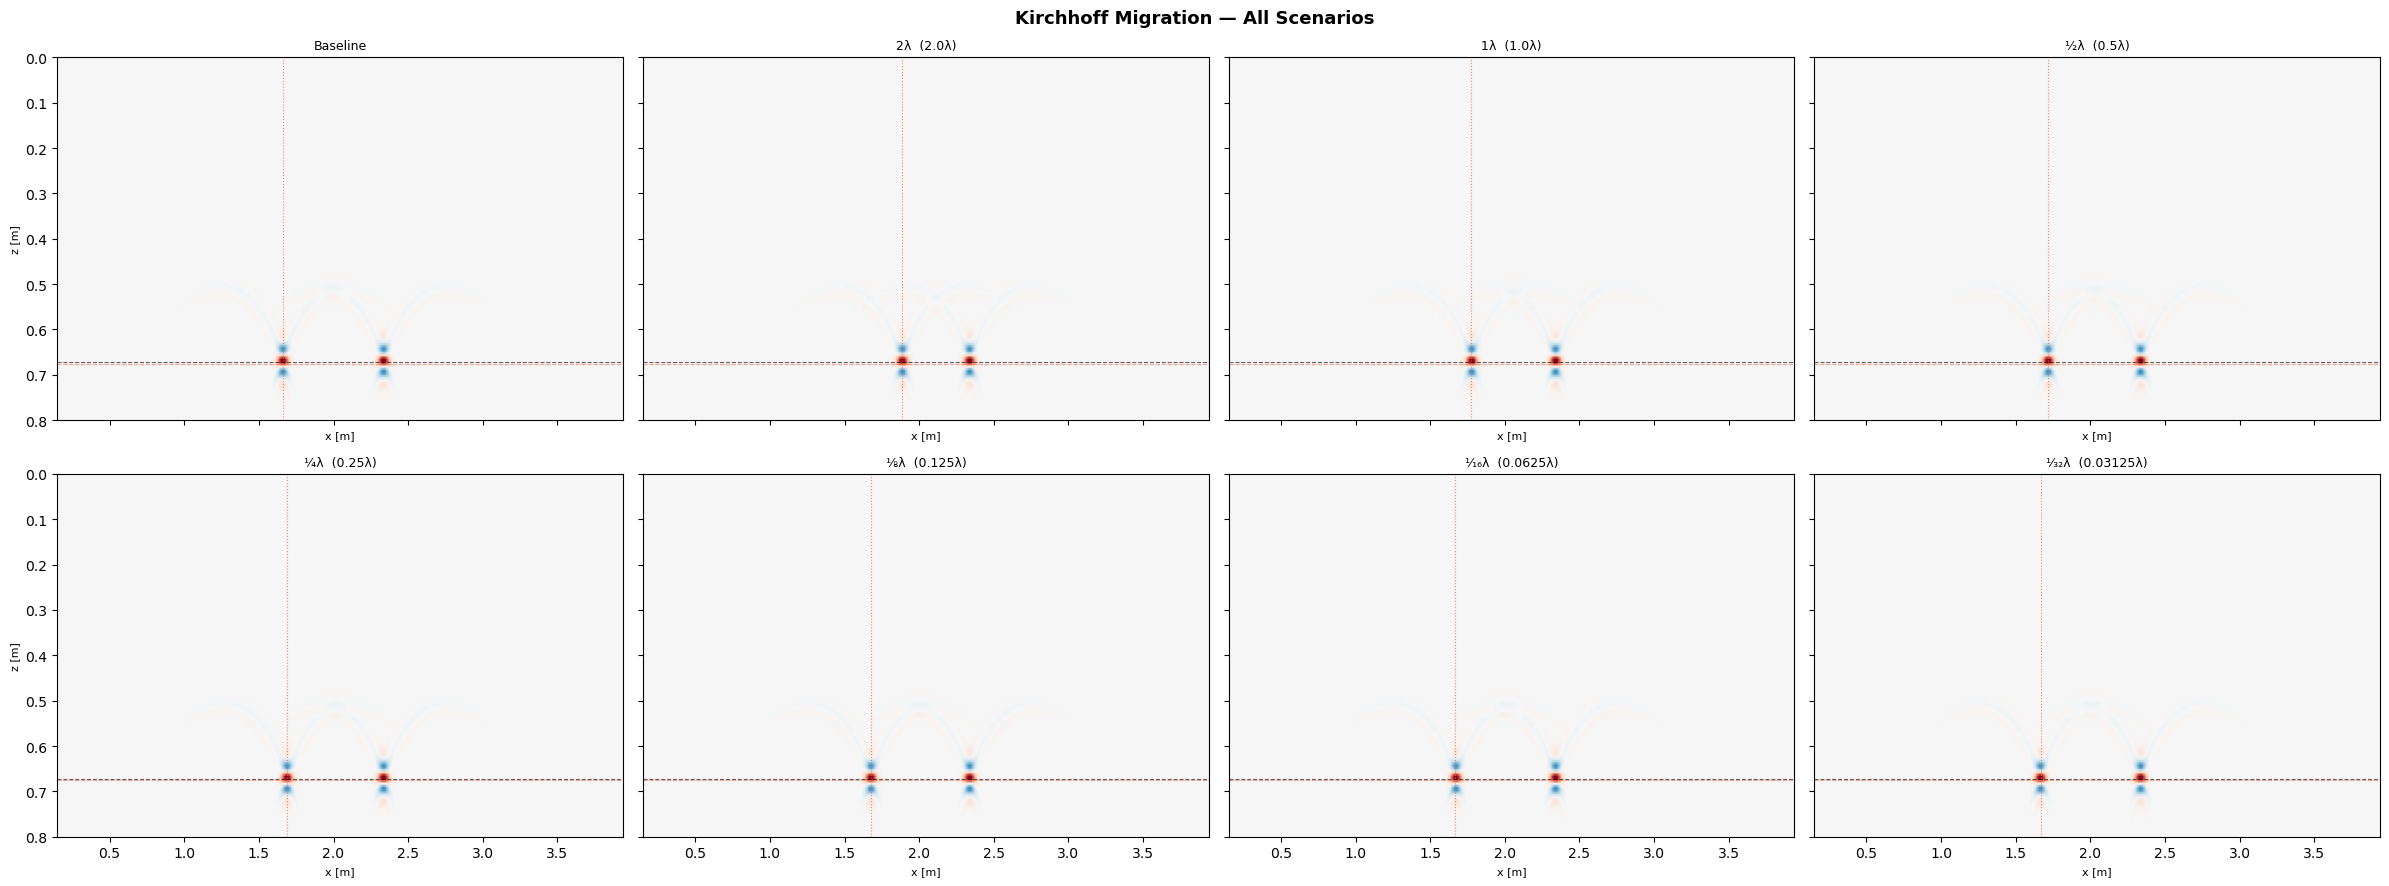

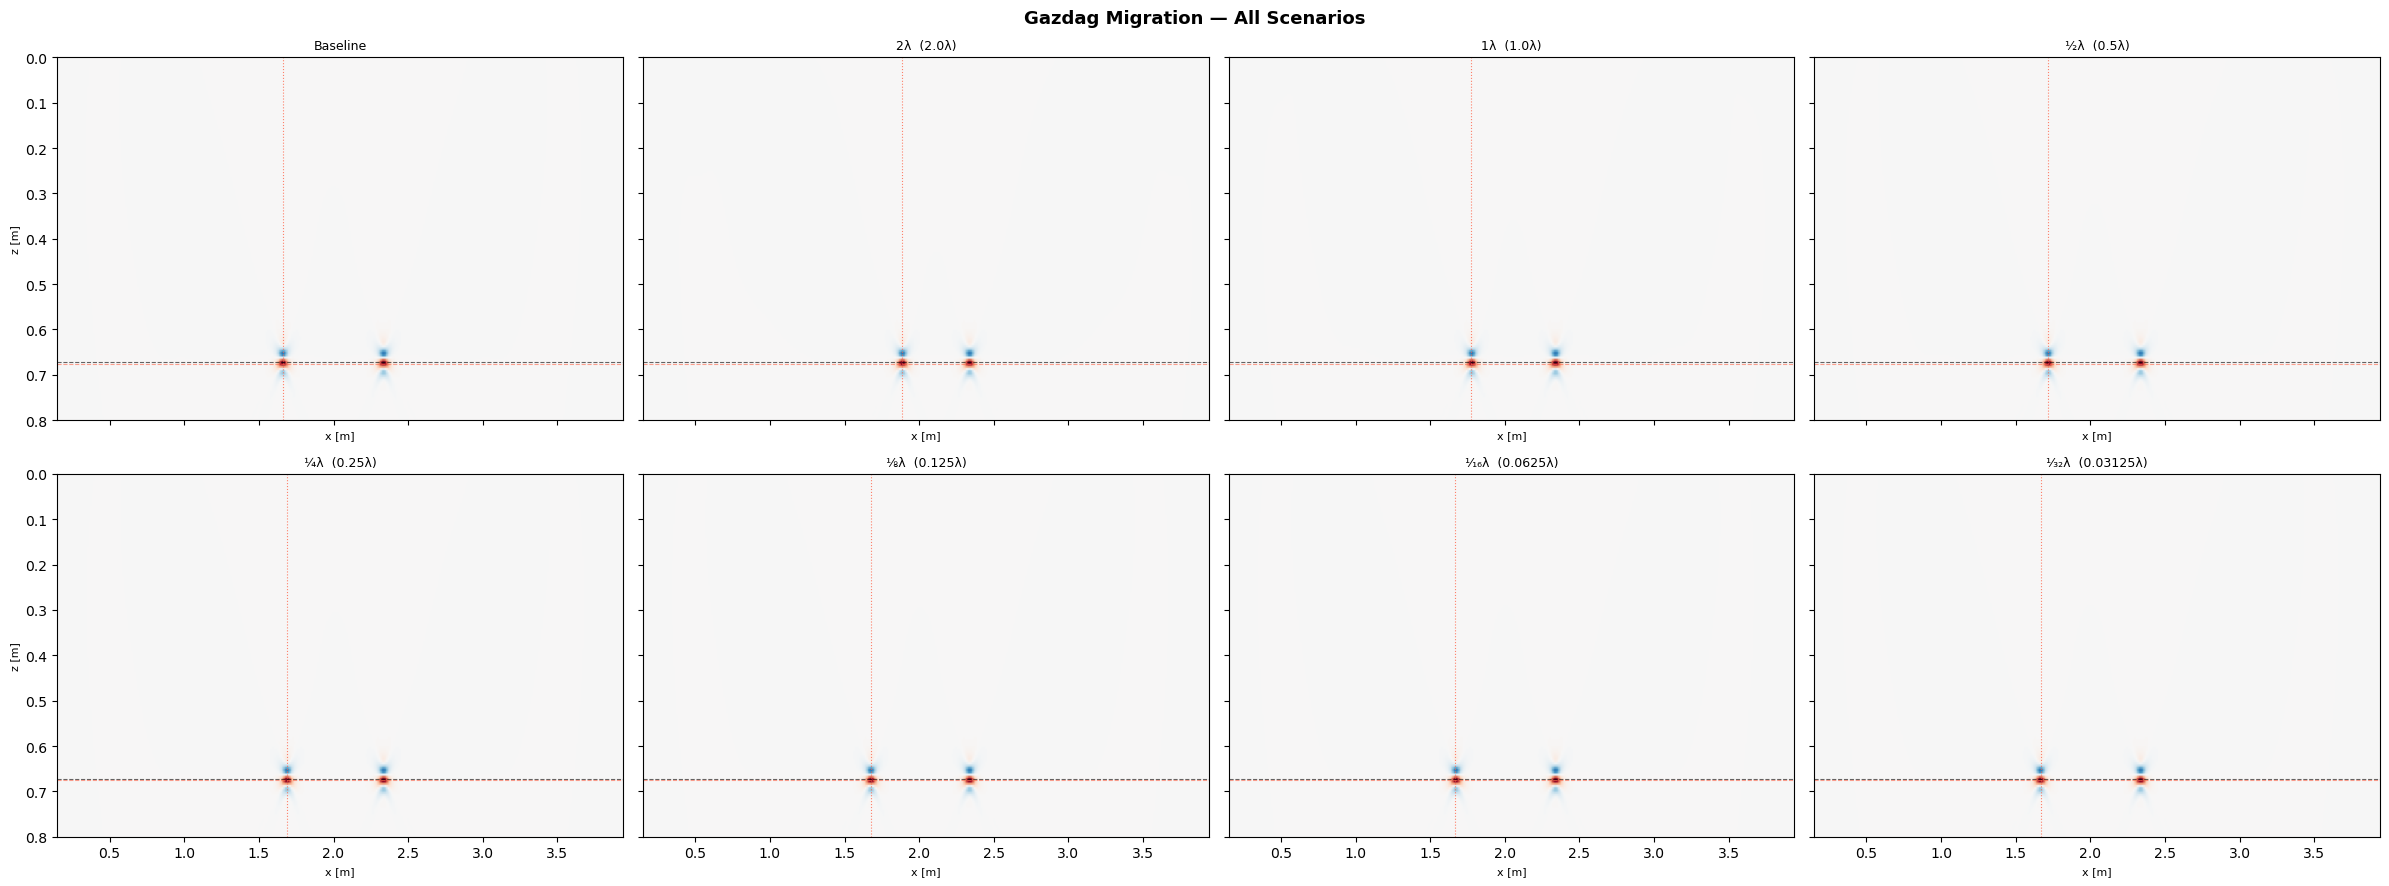

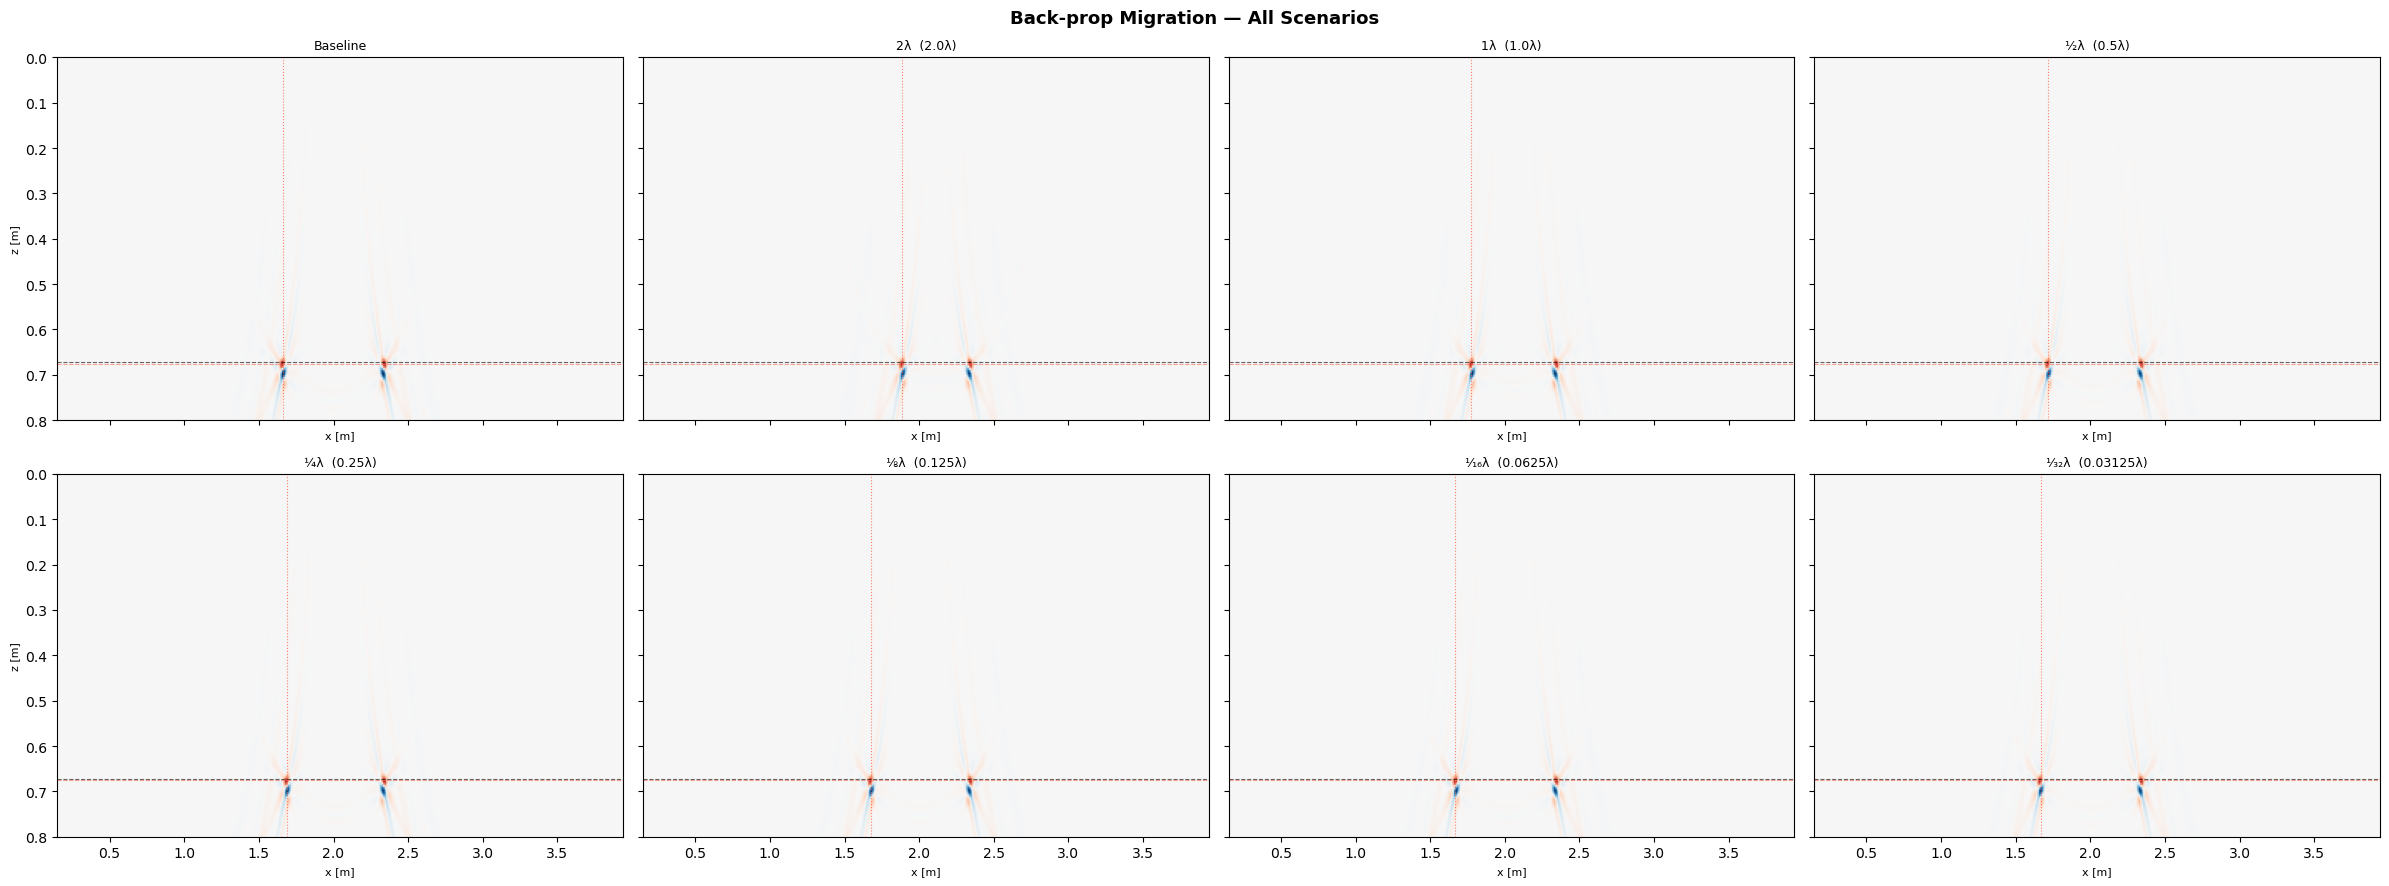

In [111]:
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]
n_scen     = len(scenarios)   # 8

method_data = [
    ('Kirchhoff', kirchhoff),
    ('Gazdag',    gazdag),
    ('Back-prop', backprop),
]

for method_name, data in method_data:
    fig, axes = plt.subplots(2, 4, figsize=(24, 9),
                             sharex=True, sharey=True, facecolor='w')
    axes_flat = axes.flatten()

    for i, (ax, lbl) in enumerate(zip(axes_flat, scenarios)):
        img  = data[i]
        vmax = np.nanpercentile(np.abs(img), 100)
        ax.imshow(img, aspect='auto', extent=extent_mig,
                  cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='upper')
        ax.axhline(z_top,        color='k',      lw=0.8, ls='--', alpha=0.6)
        ax.axhline(z_scatterer,  color='tomato',  lw=0.8, ls='--', alpha=0.6)
        ax.axvline(x_s1[i],      color='tomato',  lw=0.8, ls=':',  alpha=0.8)
        sep = separation_lambda[i]
        title = lbl if sep == 0 else f"{lbl}  ({sep}λ)"
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('x [m]', fontsize=8)
        if i % 4 == 0:
            ax.set_ylabel('z [m]', fontsize=8)


    fig.suptitle(f'{method_name} Migration — All Scenarios', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Section 2 — Phase Plane Shift Estimation

Apply `estimate_shift_2d` to each of the 7 timelapse scenarios (Monitor) vs the Baseline,
for **Kirchhoff**, **Gazdag**, and **Back-prop** migrated images.

Before calling `estimate_shift_2d`, crop each image pair to a ±2.5λ window around the
data-found scatterer apex (located from the Hilbert-envelope difference peak, then refined
on the baseline envelope). This removes the large zero-shift background that otherwise
biases the phase-plane fit toward half the true displacement.

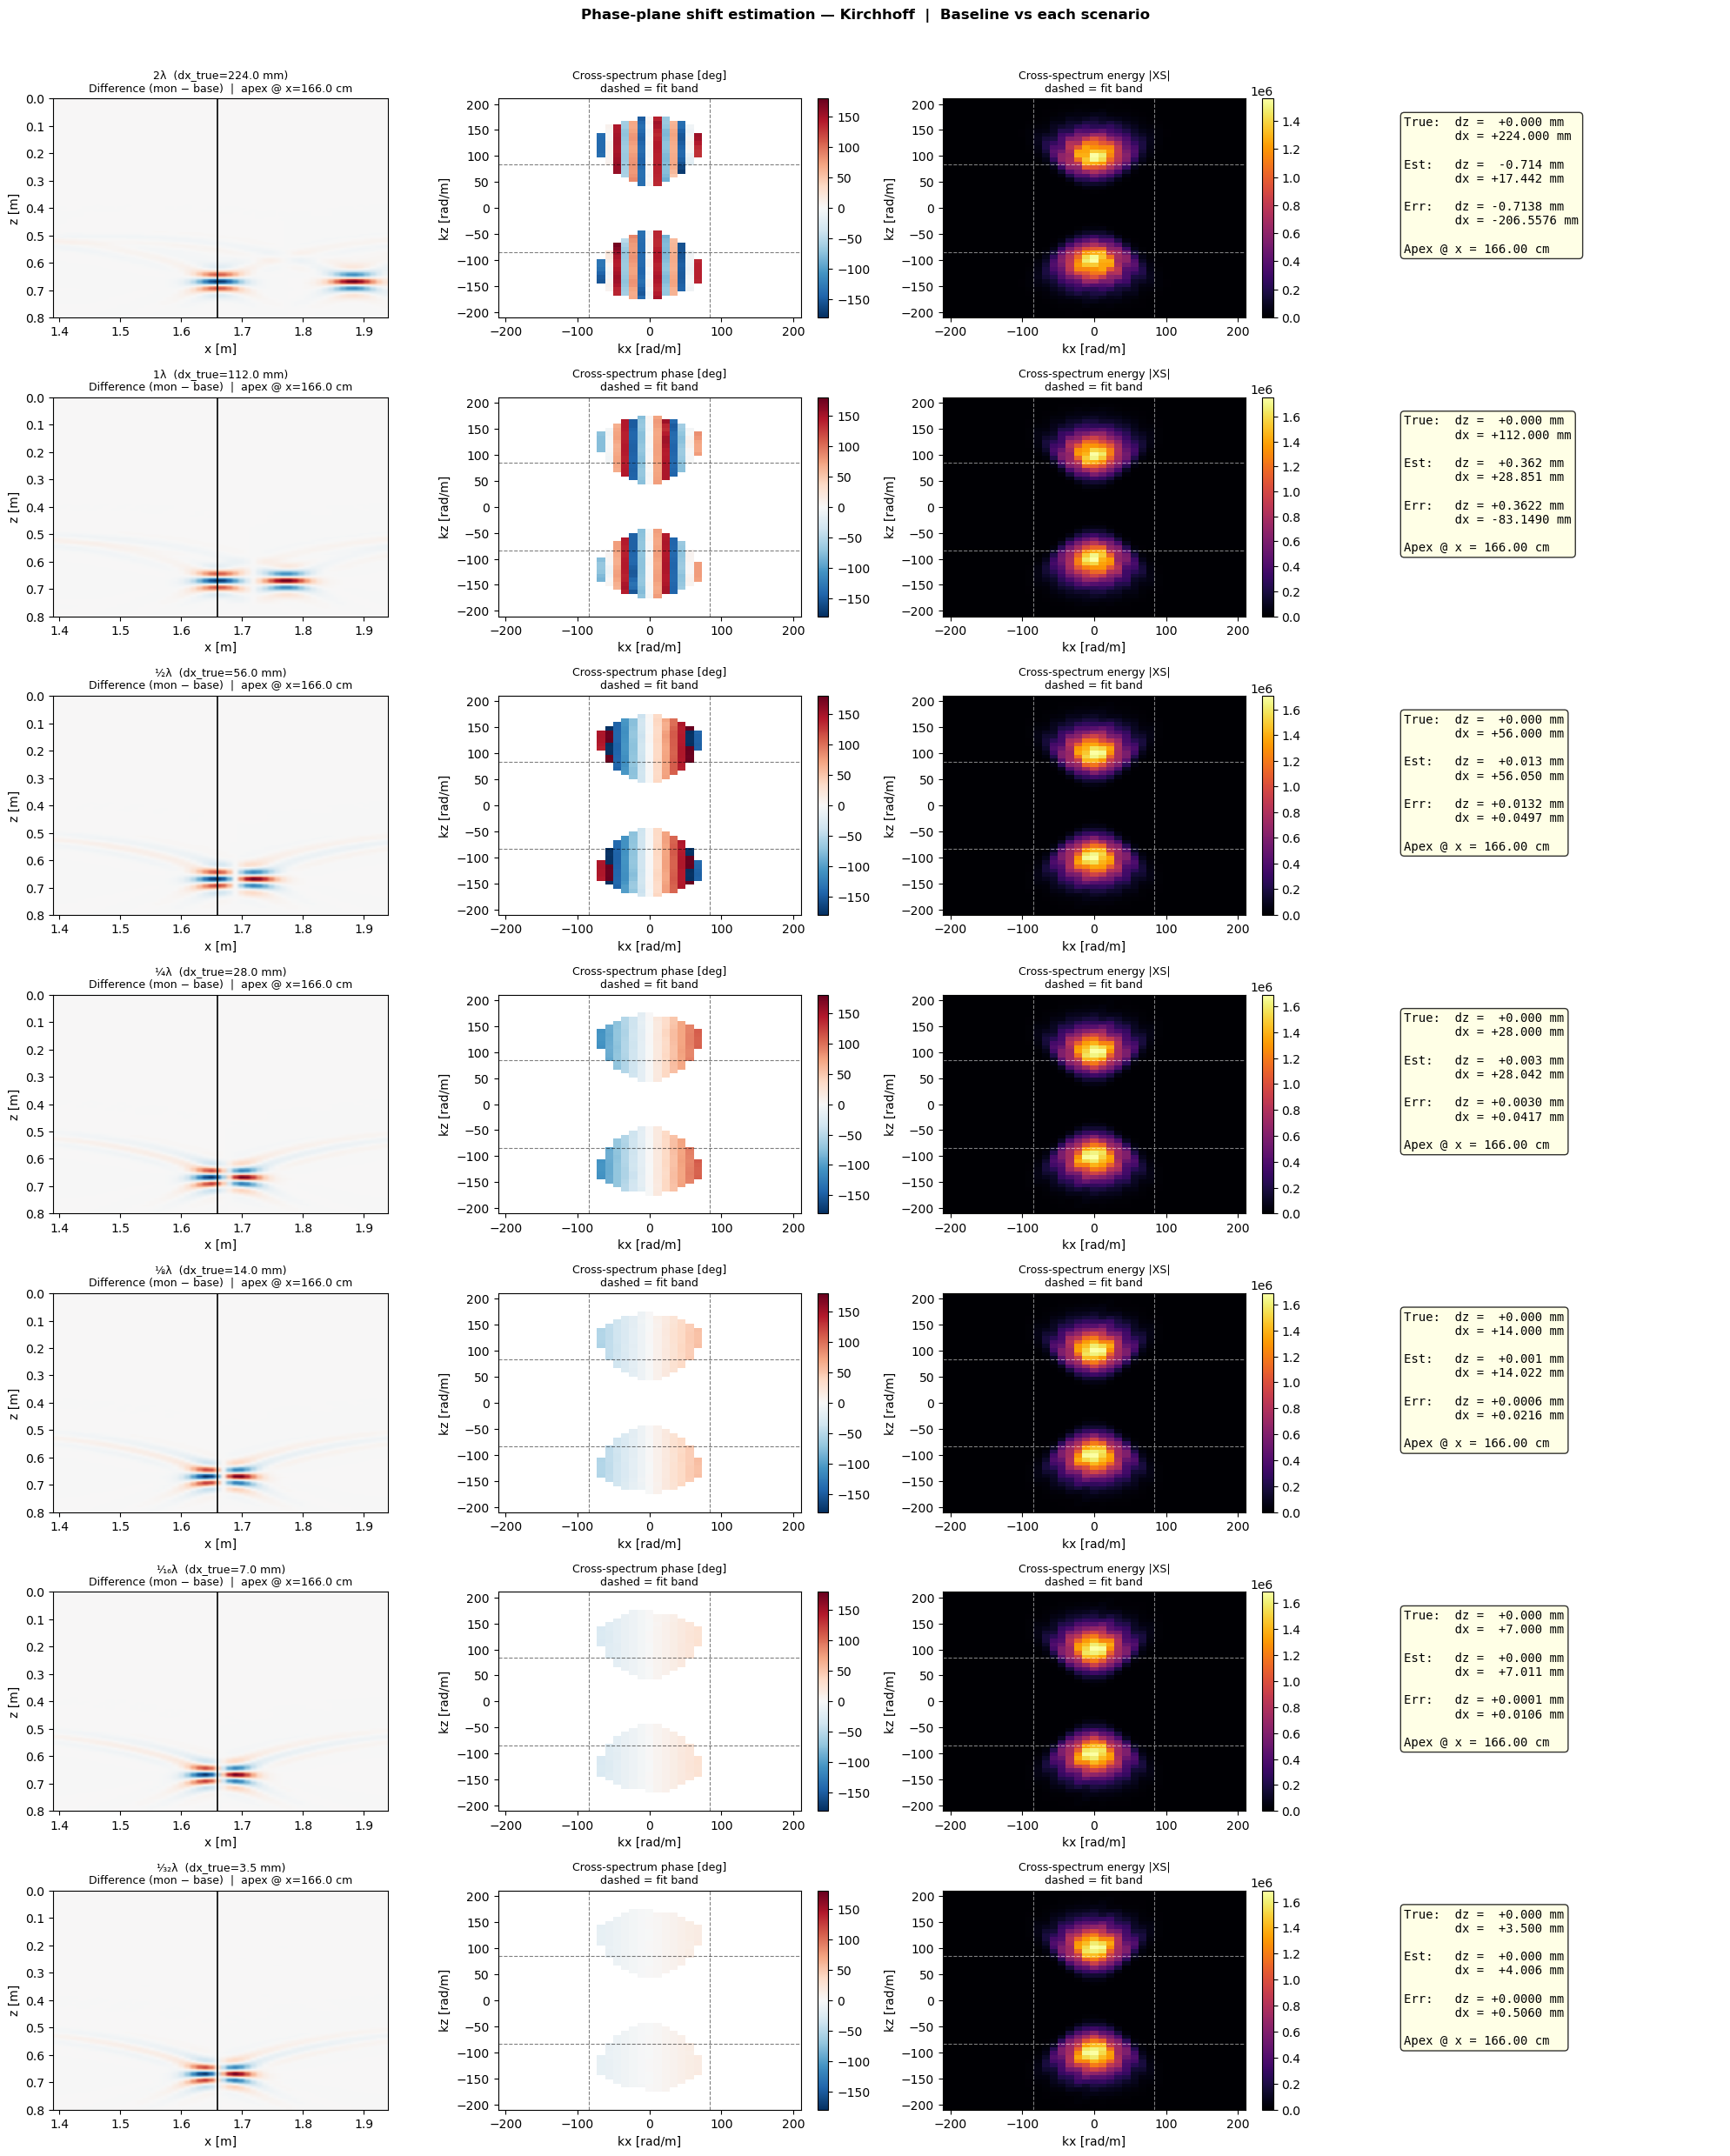

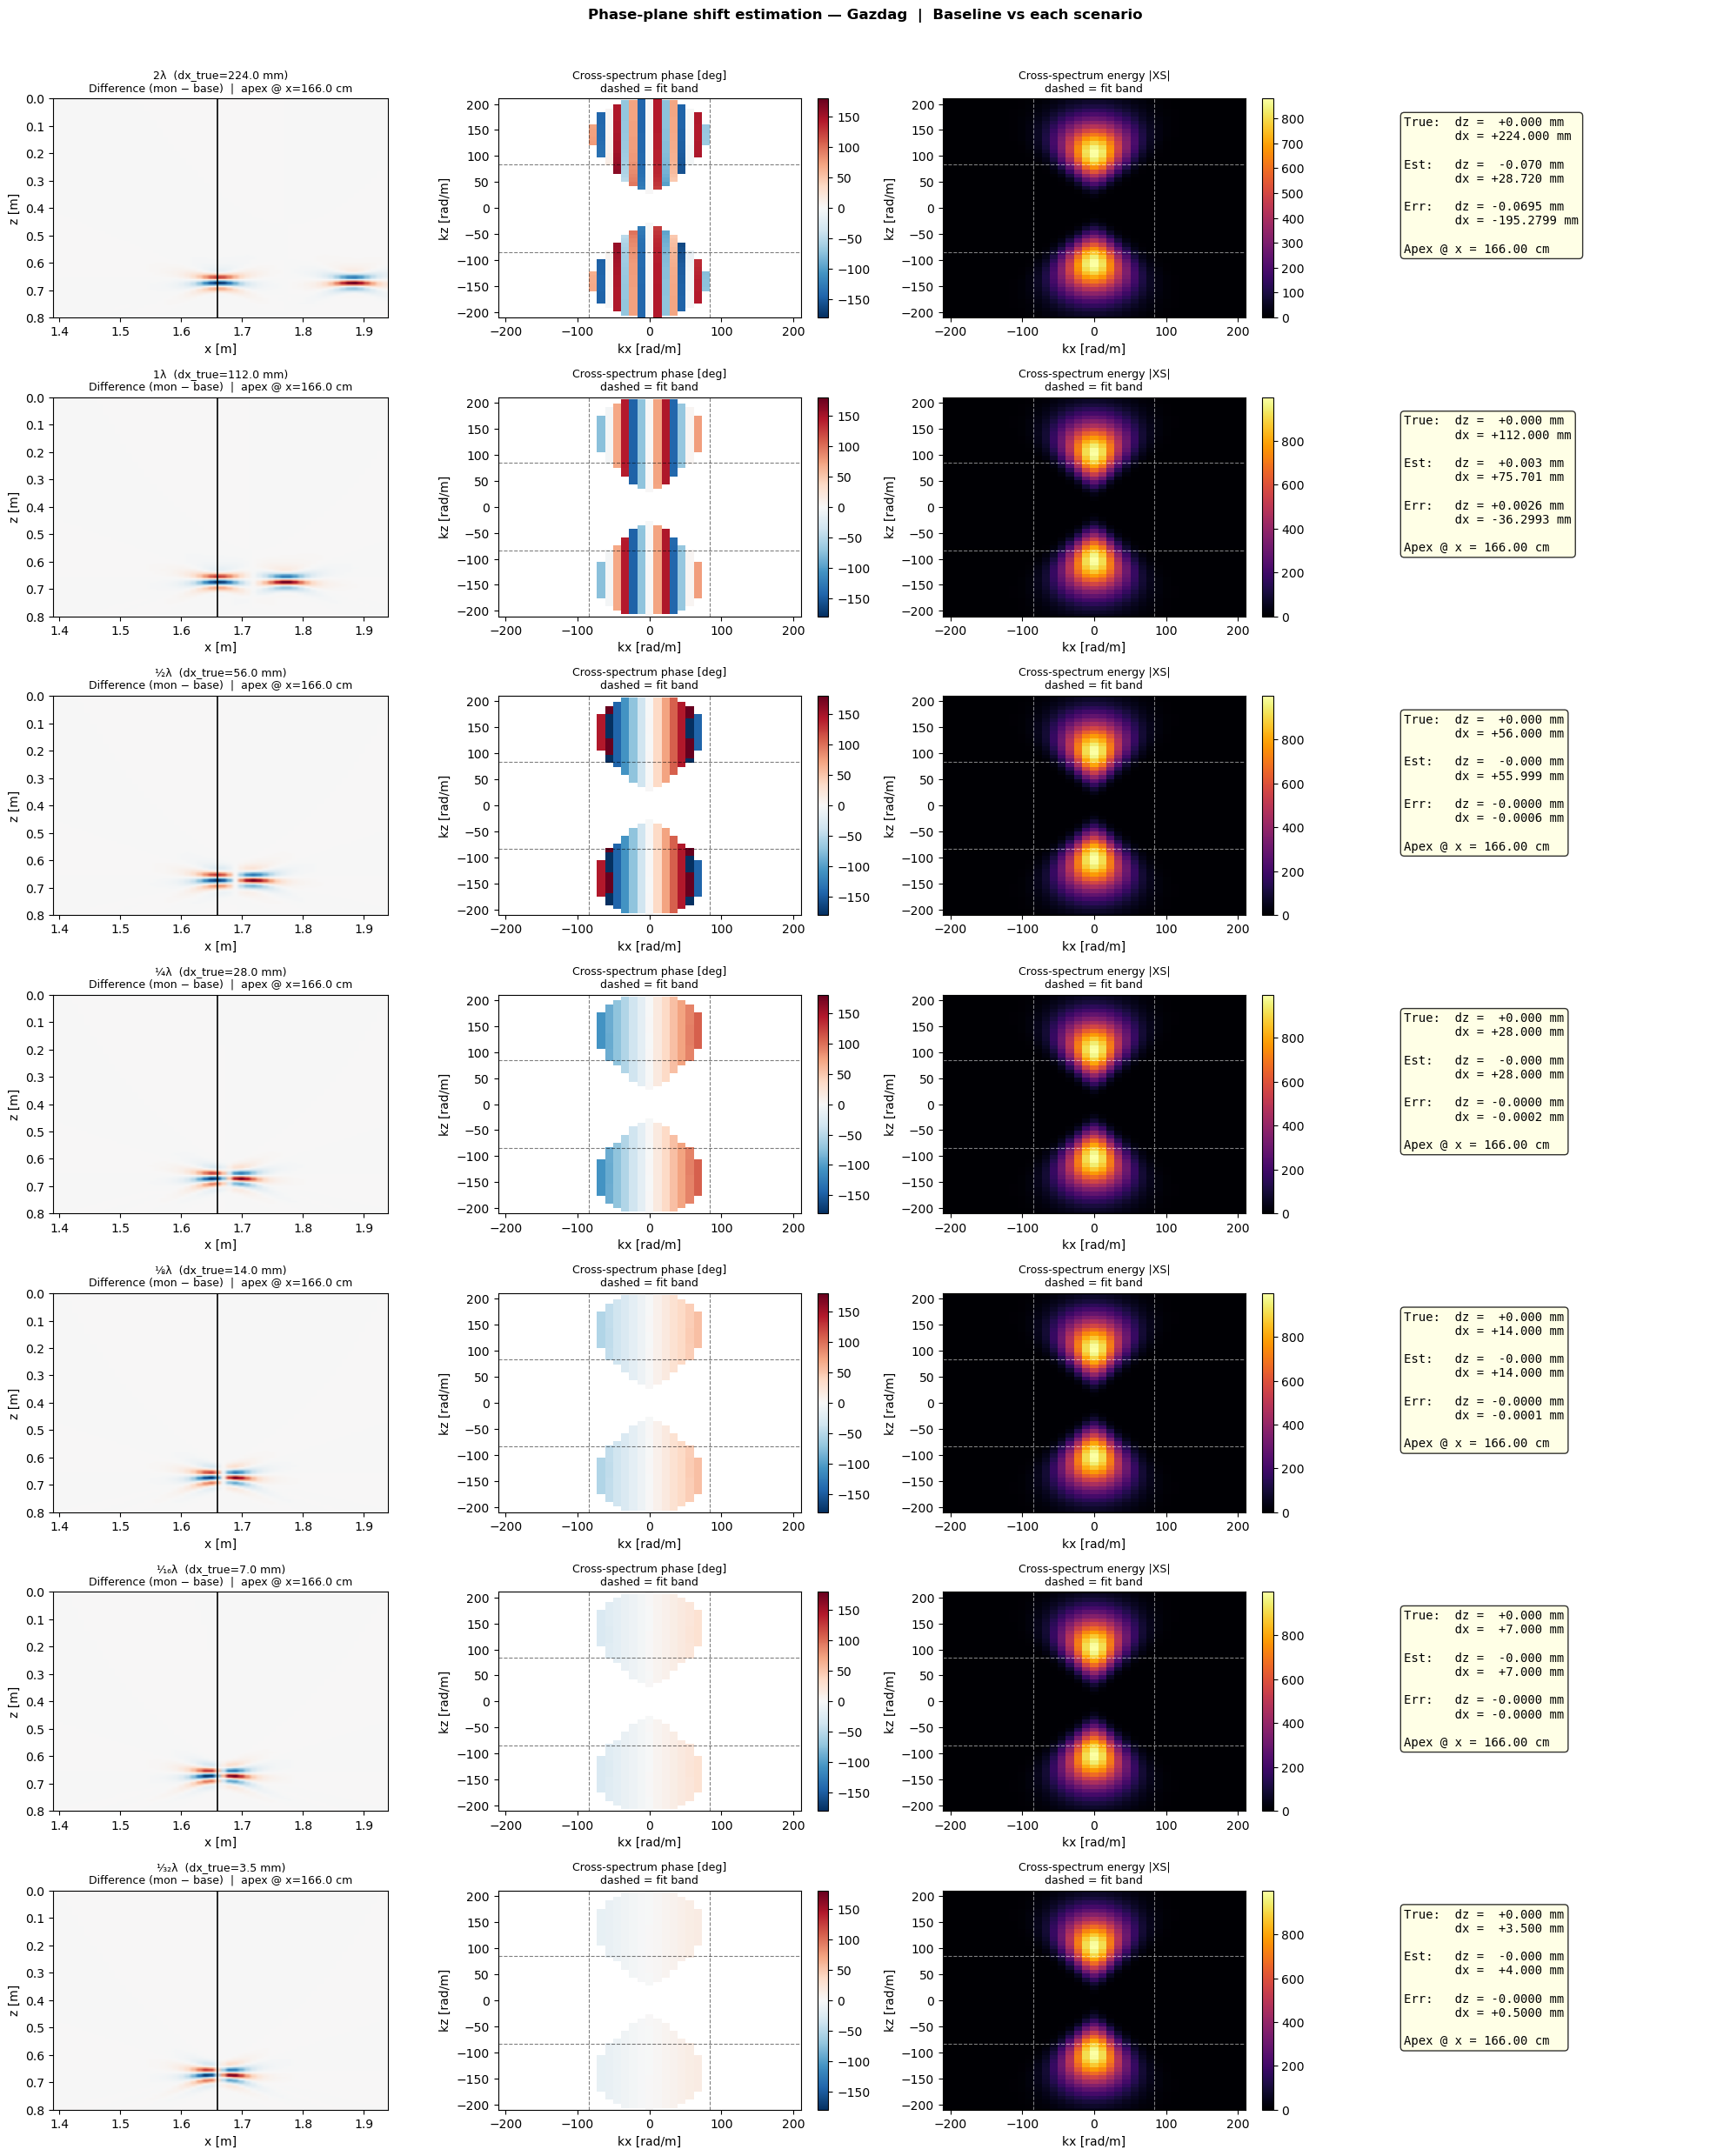

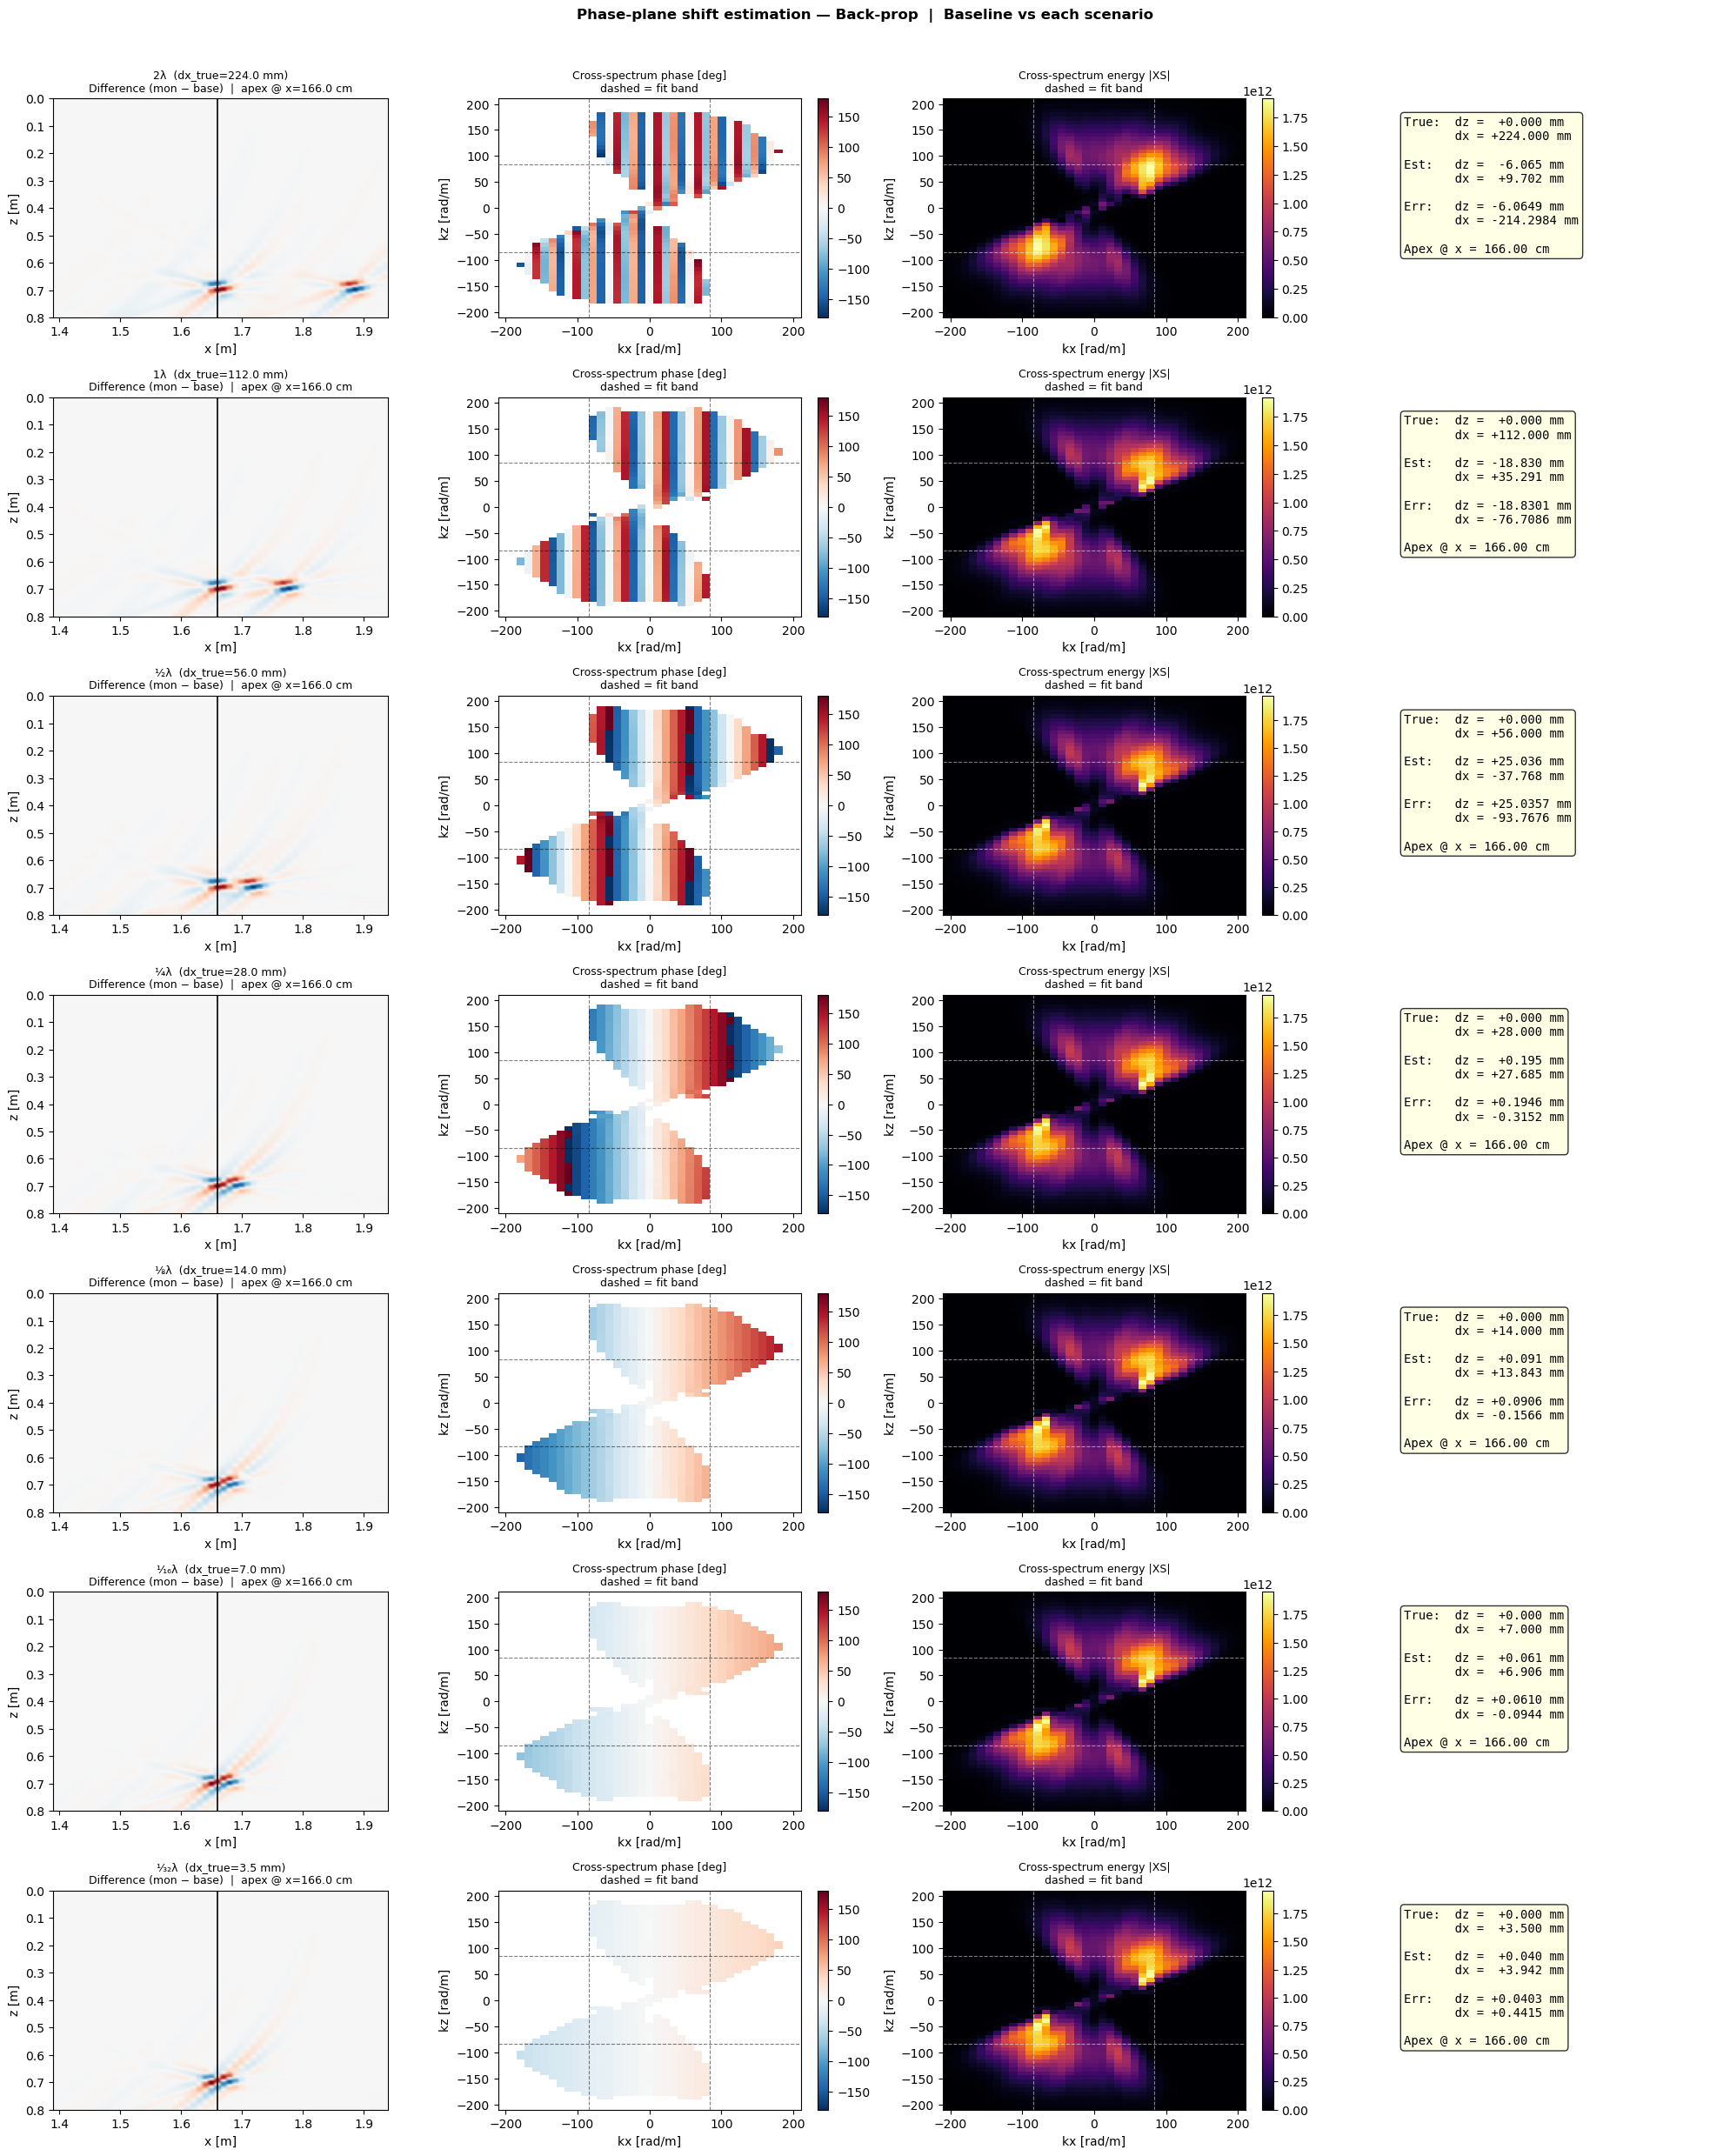

In [119]:
for method_name, base_stack in [('Kirchhoff', kirchhoff), ('Gazdag', gazdag), ('Back-prop', backprop)]:

    base_img = base_stack[0]
    # Baseline envelope computed once per method
    env_base = np.abs(sp_hilbert(np.nan_to_num(base_img), axis=0))

    mon_cases = [
        (scenarios[i], 0.0, separation_lambda[i] * lam, base_stack[i])
        for i in range(1, len(scenarios))
    ]

    n_cases = len(mon_cases)
    fig, axes = plt.subplots(n_cases, 4, figsize=(20, 3.5 * n_cases))
    fig.suptitle(
        f"Phase-plane shift estimation — {method_name}  |  Baseline vs each scenario",
        fontsize=12, fontweight='bold', y=1.01
    )

    for row, (name, true_dz, true_dx, mon_img) in enumerate(mon_cases):

        # ── Locate scatterer apex from difference envelope ─────────────────────
        env_mon  = np.abs(sp_hilbert(np.nan_to_num(mon_img), axis=0))
        diff_env = np.abs(env_mon - env_base)

        # Rough location: peak of difference envelope
        iz_d, ix_d = np.unravel_index(np.argmax(diff_env), diff_env.shape)
        x_rough    = x_traces[ix_d]

        # Refine: baseline envelope apex within ±3λ of rough location
        hw_search = 3 * lam
        ix_lo_s   = np.searchsorted(x_traces, x_rough - hw_search)
        ix_hi_s   = np.searchsorted(x_traces, x_rough + hw_search)
        _, ix_loc = np.unravel_index(
            np.argmax(env_base[:, ix_lo_s:ix_hi_s]),
            env_base[:, ix_lo_s:ix_hi_s].shape
        )
        x_apex = x_traces[ix_lo_s + ix_loc]

        # ── Crop ±2.5λ around apex ────────────────────────────────────────────
        x_crop_hw = 2.5 * lam
        ix_lo     = np.searchsorted(x_traces, x_apex - x_crop_hw)
        ix_hi     = np.searchsorted(x_traces, x_apex + x_crop_hw)
        x_crop    = x_traces[ix_lo:ix_hi]

        base_crop = base_img[:, ix_lo:ix_hi]
        mon_crop  = mon_img[:, ix_lo:ix_hi]

        # ── Estimate shift (real images, Hermitian XS) ────────────────────────
        dz_est, dx_est, _, XS, kz_ax, kx_ax = estimate_shift_2d(
            base_crop, mon_crop, dz_mig, dx_mig, kz_c
        )

        XS_s     = np.fft.fftshift(XS)
        kz_s     = np.fft.fftshift(kz_ax)
        kx_s     = np.fft.fftshift(kx_ax)
        energy   = np.abs(XS_s)
        phi_show = np.where(energy > 0.05 * energy.max(),
                            np.degrees(np.angle(XS_s)), np.nan)

        klim        = 1.5 * kz_c
        extent_crop = [x_crop[0], x_crop[-1], z_img[-1], z_img[0]]

        # Col 0: difference image over cropped region
        ax0  = axes[row, 0]
        diff = mon_crop - base_crop
        vmax = np.nanmax(np.abs(diff))
        ax0.imshow(diff, aspect='auto', extent=extent_crop,
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='upper')
        ax0.axvline(x_apex, color='k', lw=1.2, ls='-', label='apex (data)')
        ax0.set_title(
            f"{name}  (dx_true={true_dx*1e3:.1f} mm)\n"
            f"Difference (mon − base)  |  apex @ x={x_apex*100:.1f} cm",
            fontsize=9
        )
        ax0.set_xlabel('x [m]'); ax0.set_ylabel('z [m]')

        # Col 1: cross-spectrum phase
        ax1 = axes[row, 1]
        im1 = ax1.pcolormesh(kx_s, kz_s, phi_show,
                             cmap='RdBu_r', vmin=-180, vmax=180, shading='auto')
        for sgn in [-1, 1]:
            ax1.axhline(sgn * klim, color='k', lw=0.8, ls='--', alpha=0.5)
            ax1.axvline(sgn * klim, color='k', lw=0.8, ls='--', alpha=0.5)
        ax1.set_title("Cross-spectrum phase [deg]\ndashed = fit band", fontsize=9)
        ax1.set_xlabel('kx [rad/m]'); ax1.set_ylabel('kz [rad/m]')
        ax1.set_xlim(-klim * 2.5, klim * 2.5)
        ax1.set_ylim(-klim * 2.5, klim * 2.5)
        plt.colorbar(im1, ax=ax1, fraction=0.046)

        # Col 2: cross-spectrum energy |XS|
        ax2 = axes[row, 2]
        im2 = ax2.pcolormesh(kx_s, kz_s, energy,
                             cmap='inferno', shading='auto')
        for sgn in [-1, 1]:
            ax2.axhline(sgn * klim, color='w', lw=0.8, ls='--', alpha=0.5)
            ax2.axvline(sgn * klim, color='w', lw=0.8, ls='--', alpha=0.5)
        ax2.set_title("Cross-spectrum energy |XS|\ndashed = fit band", fontsize=9)
        ax2.set_xlabel('kx [rad/m]'); ax2.set_ylabel('kz [rad/m]')
        ax2.set_xlim(-klim * 2.5, klim * 2.5)
        ax2.set_ylim(-klim * 2.5, klim * 2.5)
        plt.colorbar(im2, ax=ax2, fraction=0.046)

        # Col 3: numerical summary
        ax3 = axes[row, 3]
        ax3.axis('off')
        txt = (
            f"True:  dz = {true_dz  * 1e3:+7.3f} mm\n"
            f"       dx = {true_dx  * 1e3:+7.3f} mm\n\n"
            f"Est:   dz = {dz_est   * 1e3:+7.3f} mm\n"
            f"       dx = {dx_est   * 1e3:+7.3f} mm\n\n"
            f"Err:   dz = {(dz_est - true_dz) * 1e3:+.4f} mm\n"
            f"       dx = {(dx_est - true_dx) * 1e3:+.4f} mm\n\n"
            f"Apex @ x = {x_apex*100:.2f} cm"
        )
        ax3.text(0.05, 0.92, txt, transform=ax3.transAxes,
                 fontsize=10, va='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()


## Section 3 — FluidFlow: Lateral Fluid-Front Displacement

Estimate how far the fluid front moved (Δx) for each monitor scenario.

**Approach:**
1. Find x₀ (baseline fluid front) from the smallest-shift scenario's diff-envelope peak.
2. Crop ±2.5λ around x₀ so the focused edge diffraction dominates the cross-spectrum.
3. Real base vs real mon: Hermitian XS forces φ₀ = 0, WLS fits a pure kx slope → dx_raw.

**Centroid-shift correction (factor 2):**

The cross-spectrum measures the centroid shift of the changed water block, not the leading edge.
The newly filled region runs from x₀ to x₀ + Δx, so its centroid is at x₀ + Δx/2:

$$\Delta x_\text{raw} = \frac{\Delta x_\text{true}}{2} \implies \Delta x_\text{true} = 2\,\Delta x_\text{raw}$$

The 0.5 mm residual for the ¹⁄₃₂λ case is a grid-quantisation artefact (Δx = 3.5 mm < dx_mig = 10 mm).


In [113]:
FF_ROOT = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\fluidflow_study')

ff = np.load(str(FF_ROOT / 'migrated_results.npz'), allow_pickle=False)

ff_kirchhoff         = ff['kirchhoff']           # (n_scen, n_z, n_x)
ff_gazdag            = ff['gazdag']
ff_backprop          = ff['backprop']
ff_scenarios         = list(ff['scenarios'])
ff_separation_lambda = ff['separation_lambda']   # in units of lam (ice wavelength)
ff_x_traces          = ff['x_traces']
ff_z_img             = ff['z_img']
ff_z_top             = float(ff['z_top'])

# Grid spacing and wavenumber (same ice physics as TimeLapse)
ff_dz_mig = float(ff_z_img[1]     - ff_z_img[0])
ff_dx_mig = float(ff_x_traces[1]  - ff_x_traces[0])
ff_kz_c   = kz_c   # 2π / lam_ice — identical migration grid

print(f"Loaded: {FF_ROOT / 'migrated_results.npz'}")
print(f"  kirchhoff : {ff_kirchhoff.shape}")
print(f"  gazdag    : {ff_gazdag.shape}")
print(f"  backprop  : {ff_backprop.shape}")
print(f"  scenarios : {ff_scenarios}")
print(f"\nGrid spacing:  dz={ff_dz_mig*1e3:.2f} mm,  dx={ff_dx_mig*1e3:.2f} mm")

Loaded: C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\fluidflow_study\migrated_results.npz
  kirchhoff : (8, 160, 380)
  gazdag    : (8, 160, 380)
  backprop  : (8, 160, 380)
  scenarios : [np.str_('Baseline'), np.str_('2λ'), np.str_('1λ'), np.str_('½λ'), np.str_('¼λ'), np.str_('⅛λ'), np.str_('¹⁄₁₆λ'), np.str_('¹⁄₃₂λ')]

Grid spacing:  dz=5.03 mm,  dx=10.00 mm


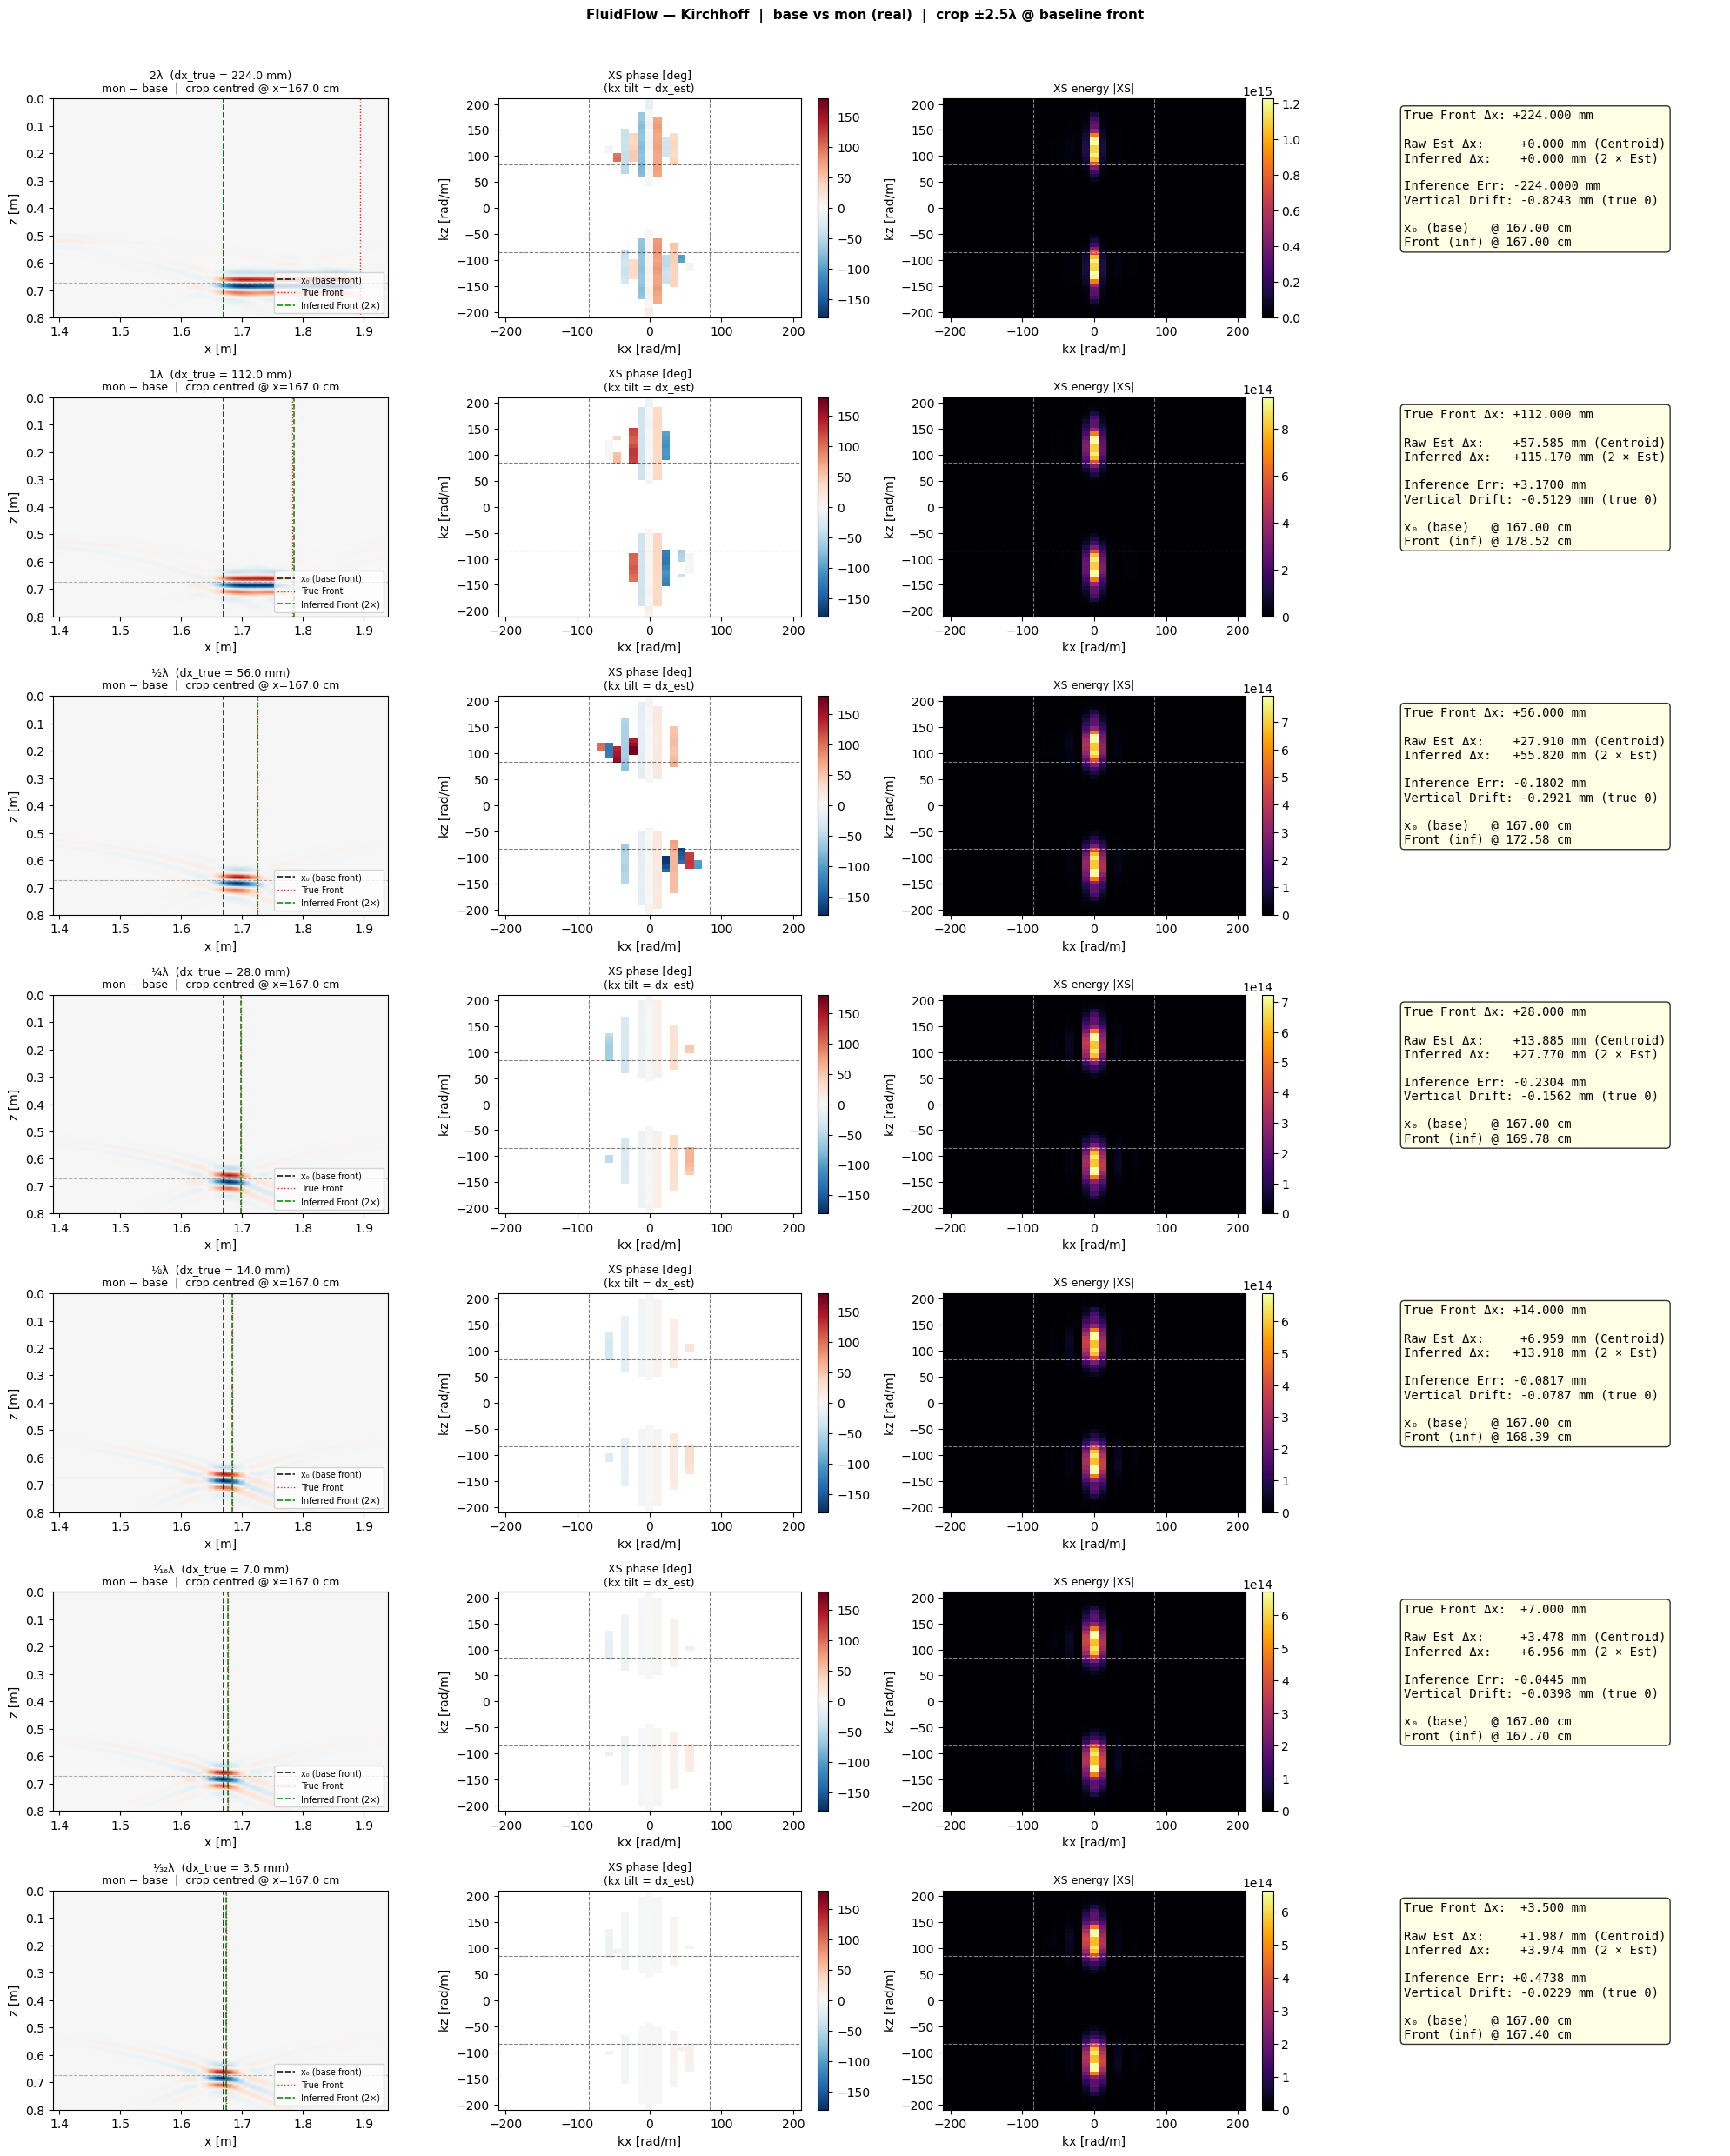

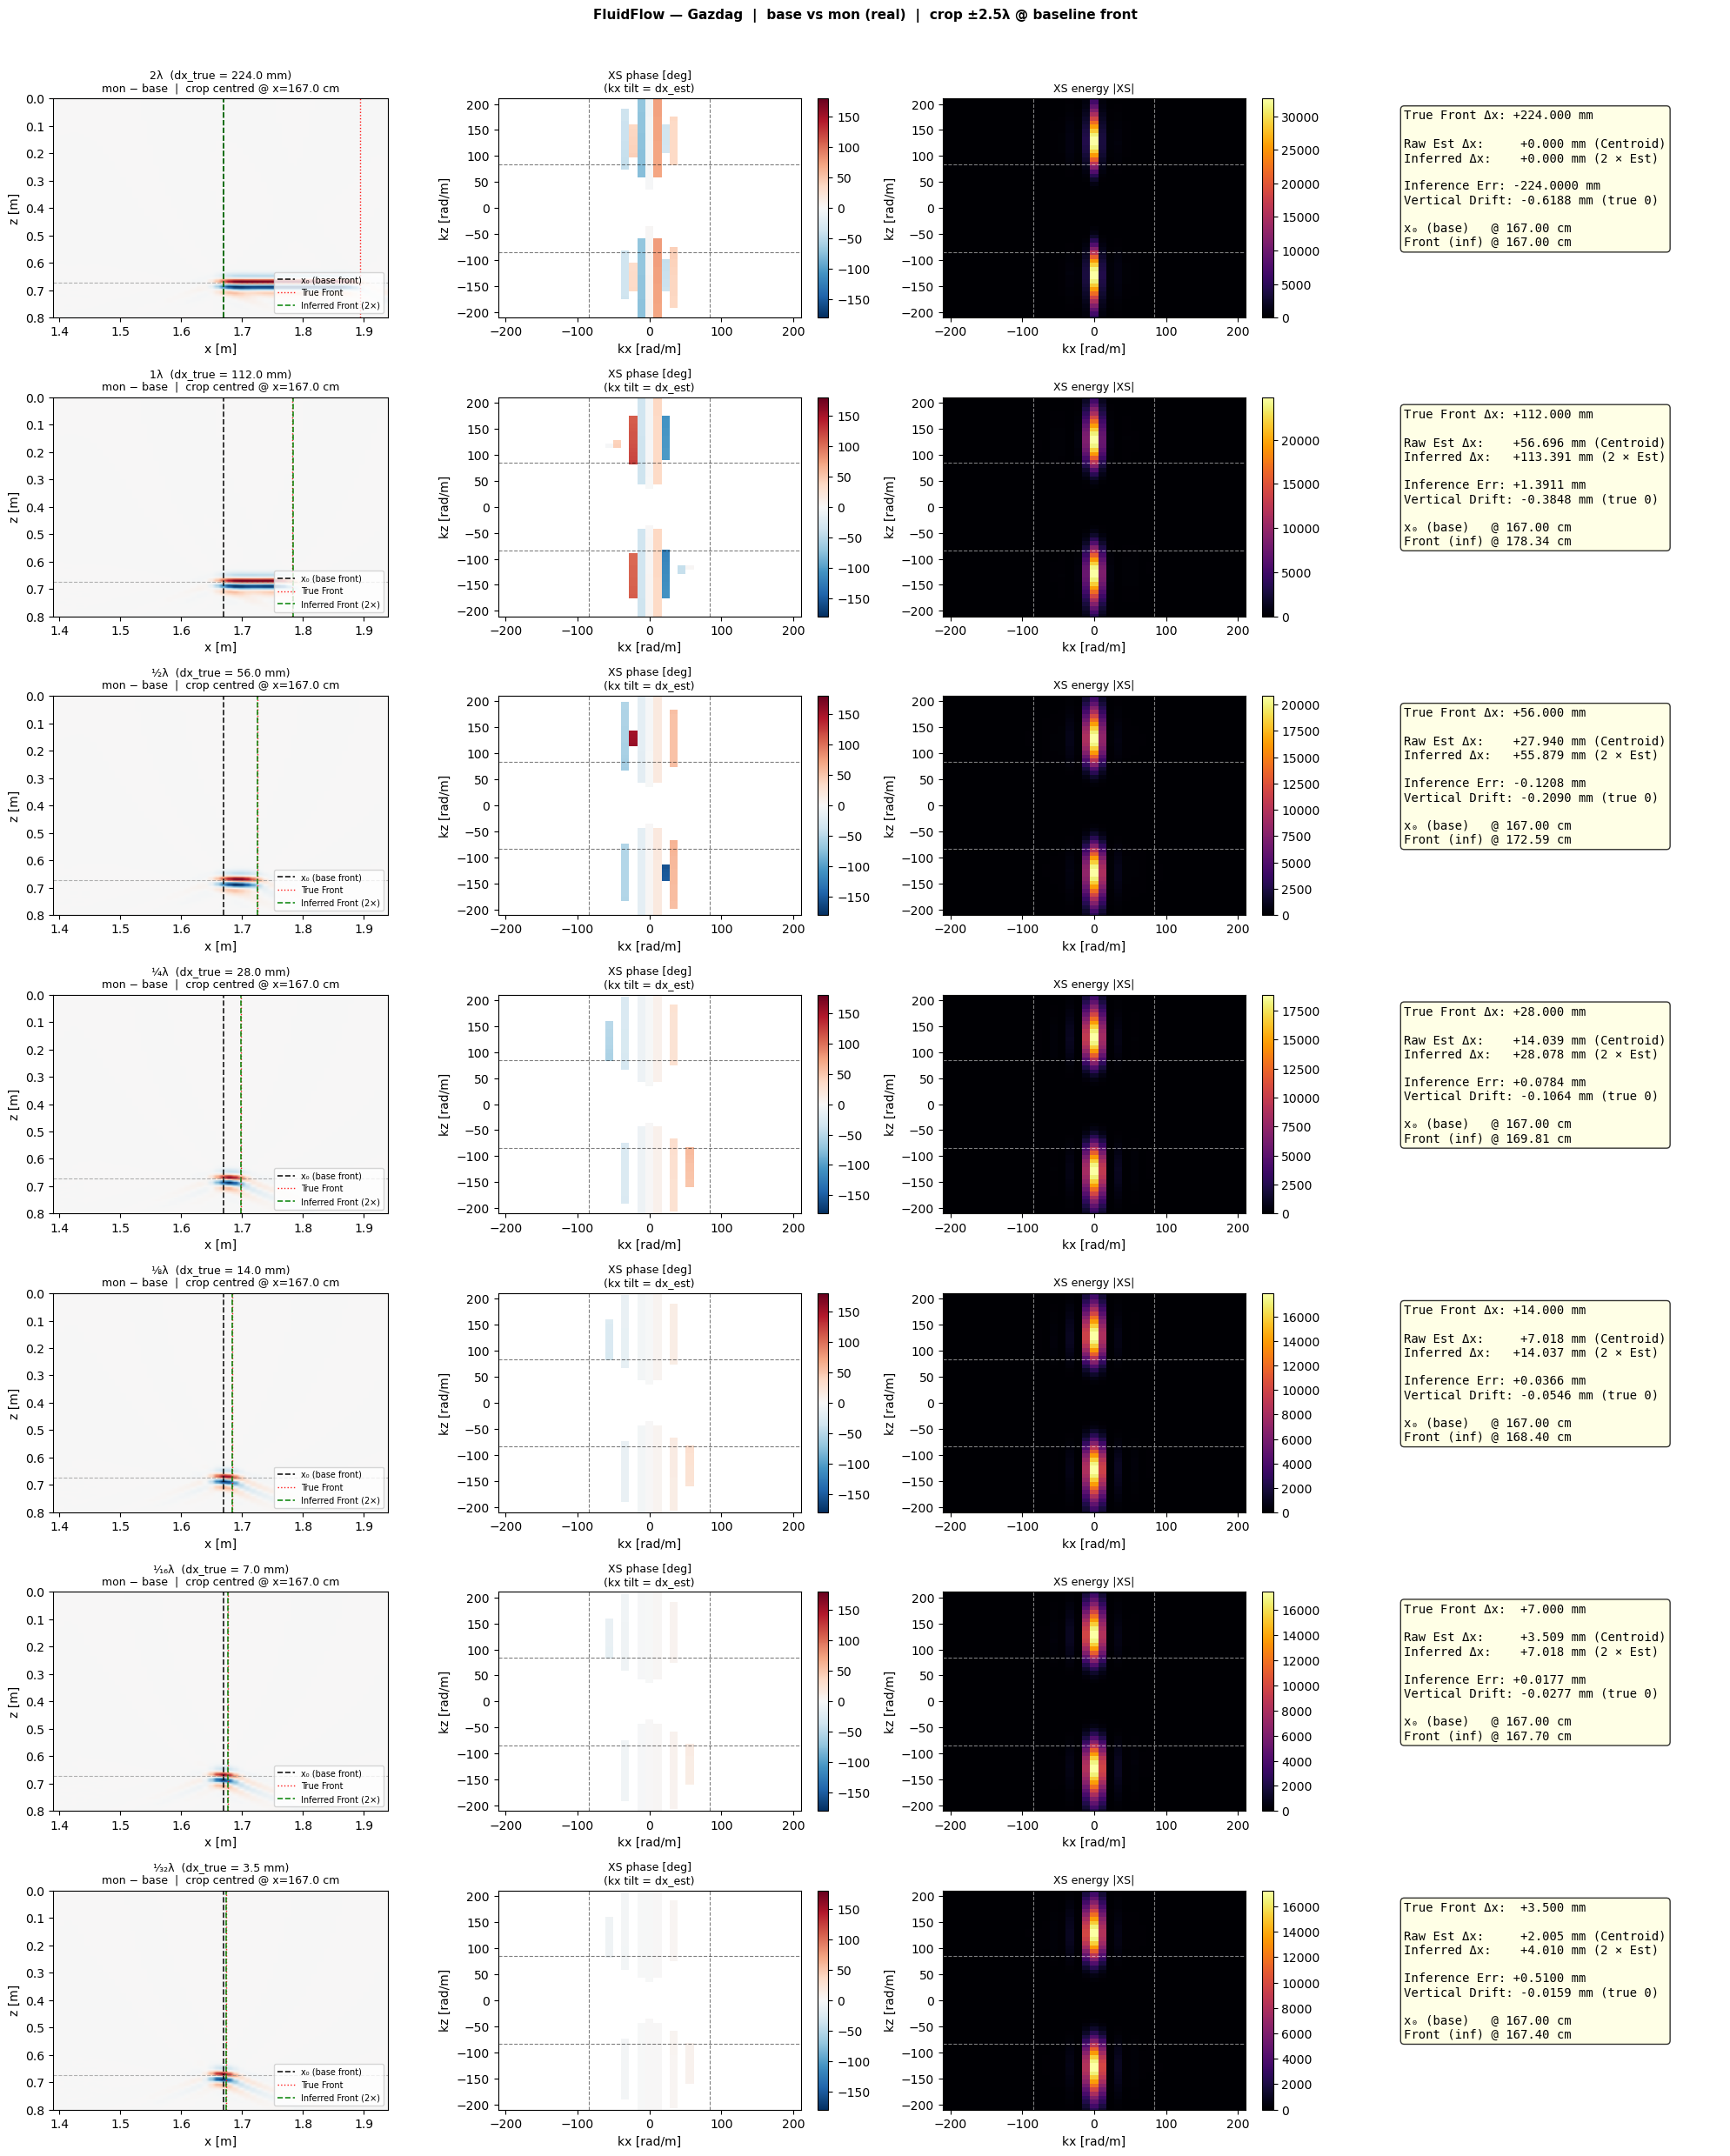

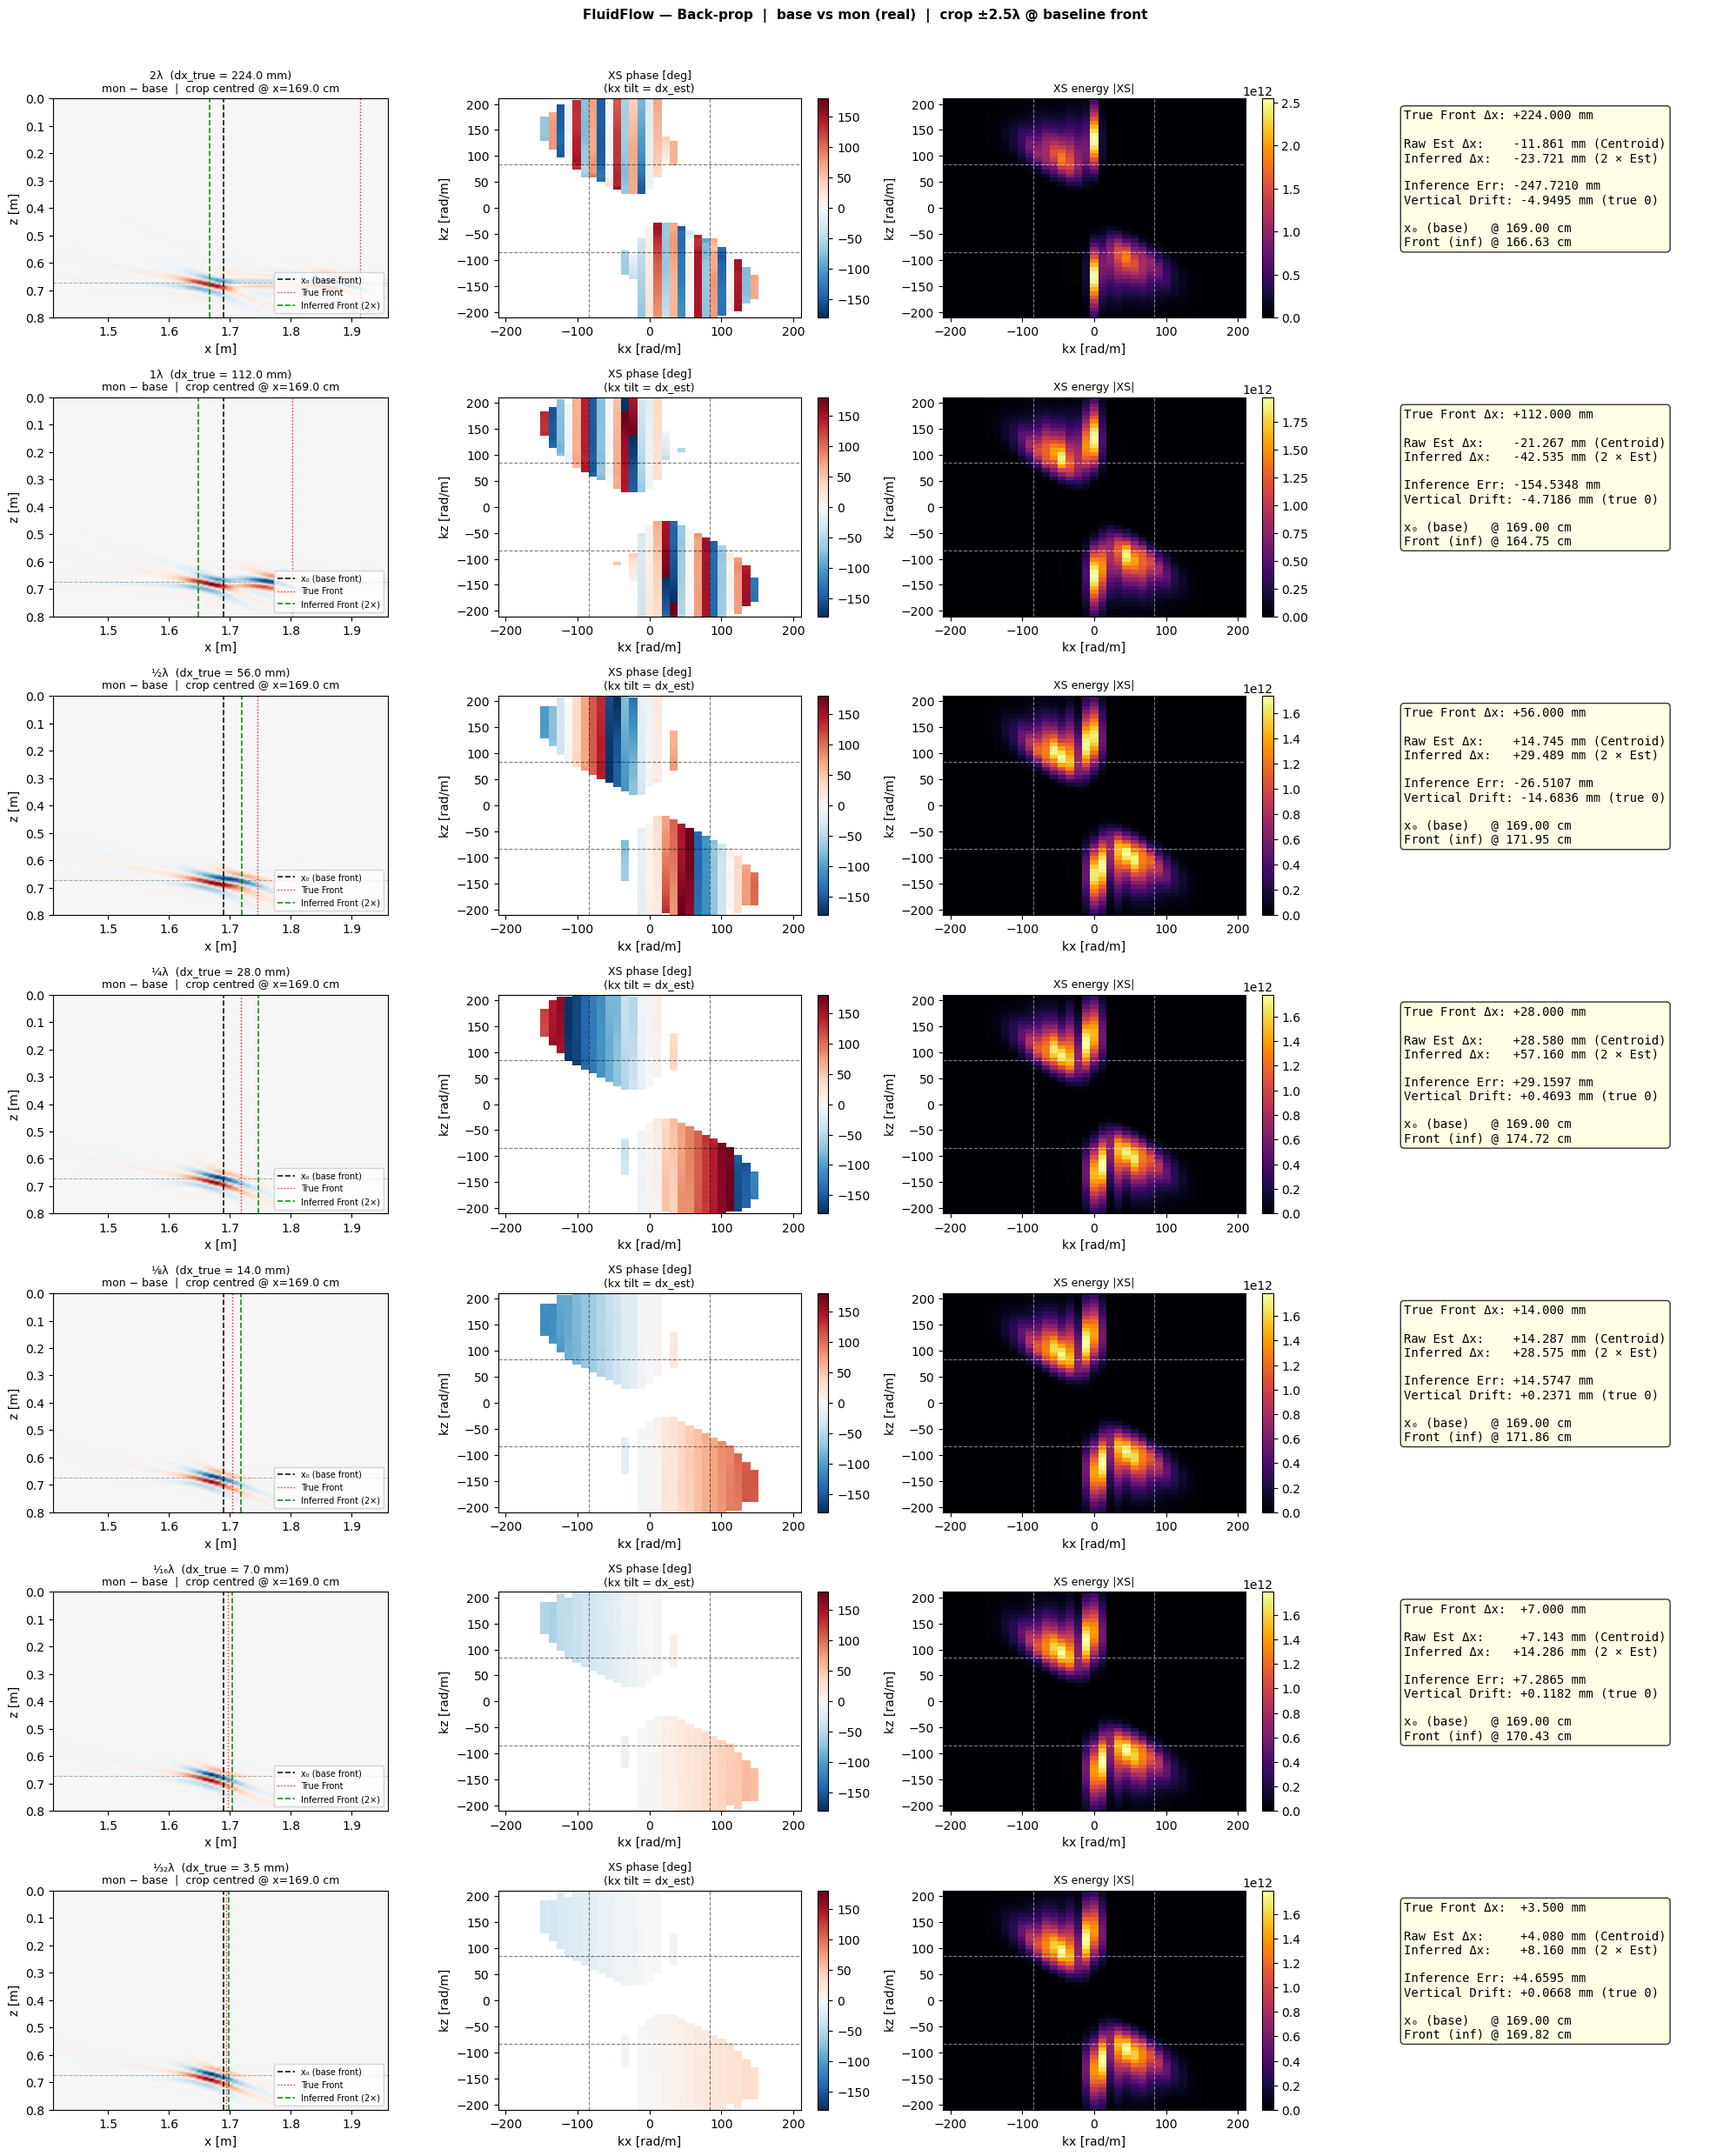

In [118]:
for method_name, base_stack in [('Kirchhoff', ff_kirchhoff), ('Gazdag', ff_gazdag), ('Back-prop', ff_backprop)]:

    base_img = base_stack[0]
    env_base = np.abs(sp_hilbert(np.nan_to_num(base_img), axis=0))

    # ── Locate baseline fluid front ────────────────────────────────────────────
    # Use the smallest-shift scenario's diff-envelope peak (≈ x₀ + λ/32 ≈ x₀).
    # This is robust against migration artifacts that can shift the global env_base
    # argmax to the wrong lateral position.
    env_ref      = np.abs(sp_hilbert(np.nan_to_num(base_stack[-1]), axis=0))
    diff_env_ref = np.abs(env_ref - env_base)
    _, ix_ref    = np.unravel_index(np.argmax(diff_env_ref), diff_env_ref.shape)
    x_apex_base  = ff_x_traces[ix_ref]

    mon_cases = [
        (ff_scenarios[i], 0.0, ff_separation_lambda[i] * lam, base_stack[i])
        for i in range(1, len(ff_scenarios))
    ]

    n_cases = len(mon_cases)
    fig, axes = plt.subplots(n_cases, 4, figsize=(20, 3.5 * n_cases))
    fig.suptitle(
        f"FluidFlow — {method_name}  |  base vs mon (real)  |  crop ±2.5λ @ baseline front",
        fontsize=11, fontweight='bold', y=1.01
    )

    for row, (name, true_dz, true_dx, mon_img) in enumerate(mon_cases):

        # ── Crop ±2.5λ around the BASELINE fluid front ────────────────────────
        x_crop_hw = 2.5 * lam
        ix_lo     = np.searchsorted(ff_x_traces, x_apex_base - x_crop_hw)
        ix_hi     = np.searchsorted(ff_x_traces, x_apex_base + x_crop_hw)
        x_crop    = ff_x_traces[ix_lo:ix_hi]

        base_crop = base_img[:, ix_lo:ix_hi]
        mon_crop  = mon_img[:,  ix_lo:ix_hi]

        # ── Phase-plane shift estimate (real images, Hermitian → phi_0 = 0) ───
        dz_est, dx_est, _, XS, kz_ax, kx_ax = estimate_shift_2d(
            base_crop, mon_crop, ff_dz_mig, ff_dx_mig, ff_kz_c
        )
        
        # ── Step 3: Upscale the centroid estimate to find the true leading front ──
        dx_front_inferred = 2.0 * dx_est
        x_front_predicted = x_apex_base + dx_front_inferred

        # ── Visualisation Updates ─────────────────────────────────────────────
        XS_s     = np.fft.fftshift(XS)
        kz_s     = np.fft.fftshift(kz_ax)
        kx_s     = np.fft.fftshift(kx_ax)
        energy   = np.abs(XS_s)
        phi_show = np.where(energy > 0.01 * energy.max(),
                            np.degrees(np.angle(XS_s)), np.nan)
        klim        = 1.5 * ff_kz_c
        extent_crop = [x_crop[0], x_crop[-1], ff_z_img[-1], ff_z_img[0]]

        # Col 0: difference image with the new Inferred Front marker
        ax0   = axes[row, 0]
        diff_ = mon_crop - base_crop
        vmax  = np.nanmax(np.abs(diff_)) or 1.0
        ax0.imshow(diff_, aspect='auto', extent=extent_crop,
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='upper')
        ax0.axvline(x_apex_base,           color='k', lw=1.2, ls='--', alpha=0.9, label='x₀ (base front)')
        ax0.axvline(x_apex_base + true_dx, color='r', lw=1.0, ls=':',  alpha=0.9, label='True Front')
        
        # GREEN dashed line tracks your scaled inference
        ax0.axvline(x_front_predicted,     color='g', lw=1.2, ls='--', alpha=0.9, label='Inferred Front (2×)')
        
        ax0.axhline(ff_z_top, color='grey', lw=0.8, ls='--', alpha=0.6)
        ax0.set_title(
            f"{name}  (dx_true = {true_dx*1e3:.1f} mm)\n"
            f"mon − base  |  crop centred @ x={x_apex_base*100:.1f} cm",
            fontsize=9
        )
        ax0.set_xlabel('x [m]'); ax0.set_ylabel('z [m]')
        ax0.legend(fontsize=7, loc='lower right')

        # Col 1: cross-spectrum phase  (should be a kx-slope = dx)
        ax1 = axes[row, 1]
        im1 = ax1.pcolormesh(kx_s, kz_s, phi_show,
                             cmap='RdBu_r', vmin=-180, vmax=180, shading='auto')
        for sgn in [-1, 1]:
            ax1.axhline(sgn * klim, color='k', lw=0.8, ls='--', alpha=0.5)
            ax1.axvline(sgn * klim, color='k', lw=0.8, ls='--', alpha=0.5)
        ax1.set_title("XS phase [deg]\n(kx tilt = dx_est)", fontsize=9)
        ax1.set_xlabel('kx [rad/m]'); ax1.set_ylabel('kz [rad/m]')
        ax1.set_xlim(-klim * 2.5, klim * 2.5); ax1.set_ylim(-klim * 2.5, klim * 2.5)
        plt.colorbar(im1, ax=ax1, fraction=0.046)

        # Col 2: cross-spectrum energy
        ax2 = axes[row, 2]
        im2 = ax2.pcolormesh(kx_s, kz_s, energy, cmap='inferno', shading='auto')
        for sgn in [-1, 1]:
            ax2.axhline(sgn * klim, color='w', lw=0.8, ls='--', alpha=0.5)
            ax2.axvline(sgn * klim, color='w', lw=0.8, ls='--', alpha=0.5)
        ax2.set_title("XS energy |XS|", fontsize=9)
        ax2.set_xlabel('kx [rad/m]'); ax2.set_ylabel('kz [rad/m]')
        ax2.set_xlim(-klim * 2.5, klim * 2.5); ax2.set_ylim(-klim * 2.5, klim * 2.5)
        plt.colorbar(im2, ax=ax2, fraction=0.046)

        # Col 3: Numerical summary showing the corrected scaling
        ax3 = axes[row, 3]
        ax3.axis('off')
        txt = (
            f"True Front Δx: {true_dx * 1e3:+7.3f} mm\n\n"
            f"Raw Est Δx:    {dx_est  * 1e3:+7.3f} mm (Centroid)\n"
            f"Inferred Δx:   {dx_front_inferred * 1e3:+7.3f} mm (2 × Est)\n\n"
            f"Inference Err: {(dx_front_inferred - true_dx) * 1e3:+.4f} mm\n"
            f"Vertical Drift: {dz_est  * 1e3:+.4f} mm (true 0)\n\n"
            f"x₀ (base)   @ {x_apex_base*100:.2f} cm\n"
            f"Front (inf) @ {x_front_predicted*100:.2f} cm"
        )
        ax3.text(0.05, 0.95, txt, transform=ax3.transAxes,
                 fontsize=10, va='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()
